# Explainable Ensemble Machine Learning for Early Forest Fire Risk Prediction

## ML for Social Good Challenge

**Mission Domain:** Earth / Environment

**Problem:** Early forest-fire risk prediction

**Objective:**  
Develop an explainable ensemble machine learning system that predicts whether
environmental conditions are associated with a forest-fire event.

### Models to be compared
1. Decision Tree — baseline
2. Random Forest — bagging ensemble
3. XGBoost — boosting ensemble
4. Stacking Classifier — heterogeneous ensemble

### Explainability
SHAP will be used to explain:
- Global feature importance
- Individual predictions

### Primary evaluation metrics
- ROC-AUC
- Precision
- Recall
- F1-score
- Confusion Matrix

## 1. Dataset loading

In [267]:
# IMPORT REQUIRED LIBRARIES
# - Data loading and manipulation
# - Visualization
# - Machine learning
# - Model evaluation

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [268]:
# ============================================================
# LOAD THE RAW DATASET
# ============================================================

DATA_PATH = r"data\The extended Algerian forest fires dataset.xlsx"

# Load the Excel file
df_raw = pd.read_excel(DATA_PATH)

# We will perform cleaning on df, while df_raw remains unchanged.
df = df_raw.copy()

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 1215
Columns : 13


## 2. Dataset Overview

The dataset contains daily environmental observations associated with
different Algerian regions and periods.

The target variable is `Classes`, which indicates whether a fire was
recorded:

- `fire`
- `not fire`

The remaining variables describe weather conditions and Fire Weather
Index (FWI) components.

In [131]:
# BASIC DATASET INSPECTION

print("First 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

First 5 rows:


,DATE,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Bejaia 2021
0,2021-06-01 00:00:00,27,13,2.1,59,63.6,5.2,8.3,1.0,5.0,0.4,not fire,Bejaia 2021
1,2021-06-02 00:00:00,24,10,0.3,72,55.1,4.1,7.7,0.5,4.0,0.2,not fire,Bejaia 2021
2,2021-06-03 00:00:00,27,11,3.0,76,47.1,3.0,8.3,0.2,3.2,0.1,not fire,Bejaia 2021
3,2021-06-04 00:00:00,28,9,1.0,70,52.3,3.1,8.4,0.3,3.2,0.1,not fire,Bejaia 2021
4,2021-06-05 00:00:00,28,11,0.1,64,73.4,4.5,16.9,1.6,5.4,0.7,not fire,Bejaia 2021



Dataset shape:
(1215, 13)

Column names:
['DATE', 'Temperature', '        Ws', '    Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']

Data types:
DATE            object
Temperature      int64
        Ws       int64
    Rain       float64
RH               int64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Classes         object
Bejaia 2021     object
dtype: object


In [132]:
# CELL 4: STANDARDIZE COLUMN NAMES
# The raw Excel file contains unnecessary spaces in some column names. Removing them makes the dataset easier and safer to work with.

df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['DATE', 'Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Bejaia 2021']


In [133]:
# ============================================================
# CELL 5: INSPECT THE TARGET VARIABLE
# ============================================================
# This cell checks the unique target values and their
# frequencies.
#
# This is important because classification models require
# a clean and consistent target representation.
# ============================================================

print("Unique target values before cleaning:")
print(df["Classes"].unique())

print("\nTarget value counts:")
print(df["Classes"].value_counts(dropna=False))

Unique target values before cleaning:
['not fire' 'fire' 'fire ']

Target value counts:
Classes
fire        613
not fire    582
fire         20
Name: count, dtype: int64


In [134]:
# ============================================================
# CELL 6: CLEAN THE TARGET LABELS
# ============================================================
# Some "fire" labels contain trailing whitespace.
#
# We remove leading/trailing whitespace so that all equivalent
# labels are treated as the same class.
# ============================================================

df["Classes"] = df["Classes"].astype(str).str.strip().str.lower()

print("Target values after cleaning:")
print(df["Classes"].unique())

print("\nCleaned target distribution:")
print(df["Classes"].value_counts())

Target values after cleaning:
['not fire' 'fire']

Cleaned target distribution:
Classes
fire        633
not fire    582
Name: count, dtype: int64


In [135]:
# ============================================================
# CELL 7: ENCODE THE BINARY TARGET
# ============================================================
# Convert the textual target into a binary numerical target:
#
# 0 = No Fire
# 1 = Fire
#
# This encoding will be used by the machine learning models.
# ============================================================

TARGET_MAP = {
    "not fire": 0,
    "fire": 1
}

df["Fire"] = df["Classes"].map(TARGET_MAP)

print(df[["Classes", "Fire"]].head())

print("\nEncoded target distribution:")
print(df["Fire"].value_counts())

    Classes  Fire
0  not fire     0
1  not fire     0
2  not fire     0
3  not fire     0
4  not fire     0

Encoded target distribution:
Fire
1    633
0    582
Name: count, dtype: int64


## 3. Data Quality Audit

Before performing any preprocessing, the raw dataset is audited for:

- Missing values
- Duplicate observations
- Invalid data types
- Unexpected target values
- Numerical ranges
- Outliers
- Inconsistent date representations

All data-quality decisions will be documented rather than modifying
the dataset arbitrarily.

In [136]:
# ============================================================
# CELL 8: CHECK FOR MISSING VALUES

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

display(missing_summary)

,Missing Count,Missing Percentage
DATE,0,0.0
Temperature,0,0.0
Ws,0,0.0
Rain,0,0.0
RH,0,0.0
FFMC,0,0.0
DMC,0,0.0
DC,0,0.0
ISI,0,0.0
BUI,0,0.0


In [137]:
# ============================================================
# CELL 9: CHECK FOR DUPLICATE ROWS

duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

Number of exact duplicate rows: 0


In [138]:
# ============================================================
# CELL 10: CHECK DATA TYPES
# ============================================================
# This helps identify columns that may require conversion
# before machine learning.
# ============================================================

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

display(dtype_summary)

,Column,Data Type
0,DATE,object
1,Temperature,int64
2,Ws,int64
3,Rain,float64
4,RH,int64
5,FFMC,float64
6,DMC,float64
7,DC,float64
8,ISI,float64
9,BUI,float64


In [139]:
# ============================================================
# CELL 11: STANDARDIZE THE DATE COLUMN
# ============================================================
# The raw dataset contains mostly datetime values, but one
# observation is stored as an Excel serial date (44439).
#
# This function converts:
# - Existing datetime values -> unchanged
# - Excel serial numbers -> corresponding calendar dates
#
# We use Excel's standard origin date: 1899-12-30.
# ============================================================

def convert_excel_date(value):
    """
    Convert a mixed Excel date column into pandas timestamps.
    """
    
    # Already a datetime value
    if isinstance(value, (pd.Timestamp,)):
        return value
    
    # Excel serial date stored as a number
    if isinstance(value, (int, float, np.integer, np.floating)):
        return pd.Timestamp("1899-12-30") + pd.to_timedelta(value, unit="D")
    
    # Try normal date conversion for strings/other values
    return pd.to_datetime(value, errors="coerce")


df["DATE"] = df["DATE"].apply(convert_excel_date)

print("DATE column type:", df["DATE"].dtype)
print("Missing dates after conversion:", df["DATE"].isna().sum())

display(df["DATE"].head())

DATE column type: datetime64[ns]
Missing dates after conversion: 0


0   2021-06-01
1   2021-06-02
2   2021-06-03
3   2021-06-04
4   2021-06-05
Name: DATE, dtype: datetime64[ns]

In [140]:
# ============================================================
# CELL 12: VERIFY DATE CONVERSION
# ============================================================
# Check the row that previously contained the Excel serial
# date 44439.
# ============================================================

display(df.loc[818, ["DATE", "Temperature", "Rain", "RH", "Classes"]])

DATE           2021-08-31 00:00:00
Temperature                     38
Rain                           0.1
RH                              43
Classes                       fire
Name: 818, dtype: object

## 4. Numerical Feature Audit

The environmental variables are inspected for:

- Minimum values
- Maximum values
- Mean
- Median
- Standard deviation
- Potentially unusual values

This helps determine whether values are physically plausible and whether
outlier treatment is justified.

In [141]:
# ============================================================
# CELL 13: DESCRIPTIVE STATISTICS
# ============================================================
# Display summary statistics for all numerical variables.
# ============================================================

numeric_columns = [
    "Temperature",
    "Ws",
    "Rain",
    "RH",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Temperature,1215.0,33.331687,4.044168,21.0,31.00,33.0,36.00,43.0
Ws,1215.0,16.598354,5.744132,5.0,13.00,15.0,18.00,50.0
Rain,1215.0,0.401893,1.421008,0.0,0.00,0.0,0.10,20.2
RH,1215.0,52.925103,19.883064,11.0,37.00,53.0,69.00,96.0
FFMC,1215.0,83.276379,13.288328,22.5,79.80,87.5,91.90,98.6
DMC,1215.0,26.275144,22.505102,0.2,10.00,18.6,36.60,113.9
DC,1215.0,78.132181,65.917867,0.0,25.40,59.0,111.80,308.2
ISI,1215.0,9.904527,11.244088,0.0,2.50,6.7,12.60,116.7
BUI,1215.0,28.776049,23.745075,0.3,10.85,21.0,40.60,113.8
FWI,1215.0,15.497366,15.967834,0.0,3.20,11.1,21.75,102.5


In [142]:
# ============================================================
# CELL 14: CHECK BASIC DOMAIN CONSTRAINTS
# ============================================================
# These checks identify clearly invalid values.
#
# IMPORTANT:
# An extreme value is NOT automatically an invalid value.
# We only flag values that violate obvious domain constraints.
# ============================================================

domain_checks = {
    "Temperature < -50": (df["Temperature"] < -50).sum(),
    "Temperature > 60": (df["Temperature"] > 60).sum(),
    
    "Ws < 0": (df["Ws"] < 0).sum(),
    "Rain < 0": (df["Rain"] < 0).sum(),
    "RH < 0": (df["RH"] < 0).sum(),
    "RH > 100": (df["RH"] > 100).sum(),
    
    "FFMC < 0": (df["FFMC"] < 0).sum(),
    "DMC < 0": (df["DMC"] < 0).sum(),
    "DC < 0": (df["DC"] < 0).sum(),
    "ISI < 0": (df["ISI"] < 0).sum(),
    "BUI < 0": (df["BUI"] < 0).sum(),
    "FWI < 0": (df["FWI"] < 0).sum()
}

domain_check_df = pd.DataFrame(
    list(domain_checks.items()),
    columns=["Check", "Number of Violations"]
)

display(domain_check_df)

,Check,Number of Violations
0,Temperature < -50,0
1,Temperature > 60,0
2,Ws < 0,0
3,Rain < 0,0
4,RH < 0,0
5,RH > 100,0
6,FFMC < 0,0
7,DMC < 0,0
8,DC < 0,0
9,ISI < 0,0


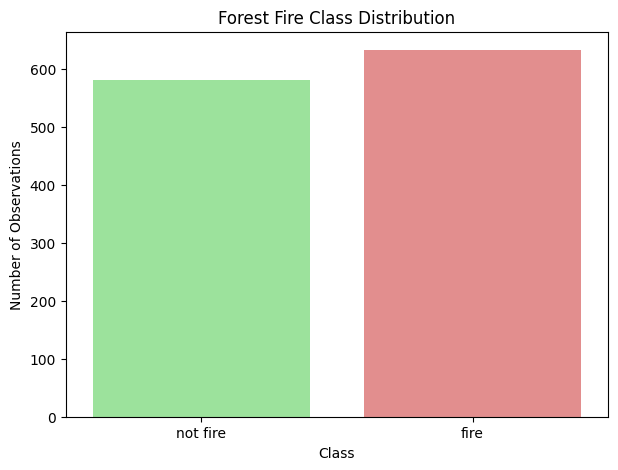

In [143]:
# ============================================================
# CELL 15: VISUALIZE TARGET DISTRIBUTION
# ============================================================
# This visualization shows the number of Fire and No Fire
# observations.
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Classes",
    order=["not fire", "fire"],
    palette=["lightgreen", "lightcoral"]
)

plt.title("Forest Fire Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")

plt.show()

### Conclusion

The dataset contains 633 fire observations (52.10%) and 582 non-fire observations (47.90%). The classes are relatively well balanced, with only a small difference between them. Therefore, severe class-imbalance correction is not immediately necessary, although class-wise performance will still be monitored during model evaluation.

In [144]:
# ============================================================
# CELL 16: TARGET CLASS PERCENTAGES
# ============================================================
# Calculate the percentage of observations belonging to each
# target class.
# ============================================================

class_distribution = (
    df["Classes"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

class_distribution["Percentage"] = (
    class_distribution["Count"] / len(df) * 100
)

display(class_distribution)

,Class,Count,Percentage
0,fire,633,52.098765
1,not fire,582,47.901235


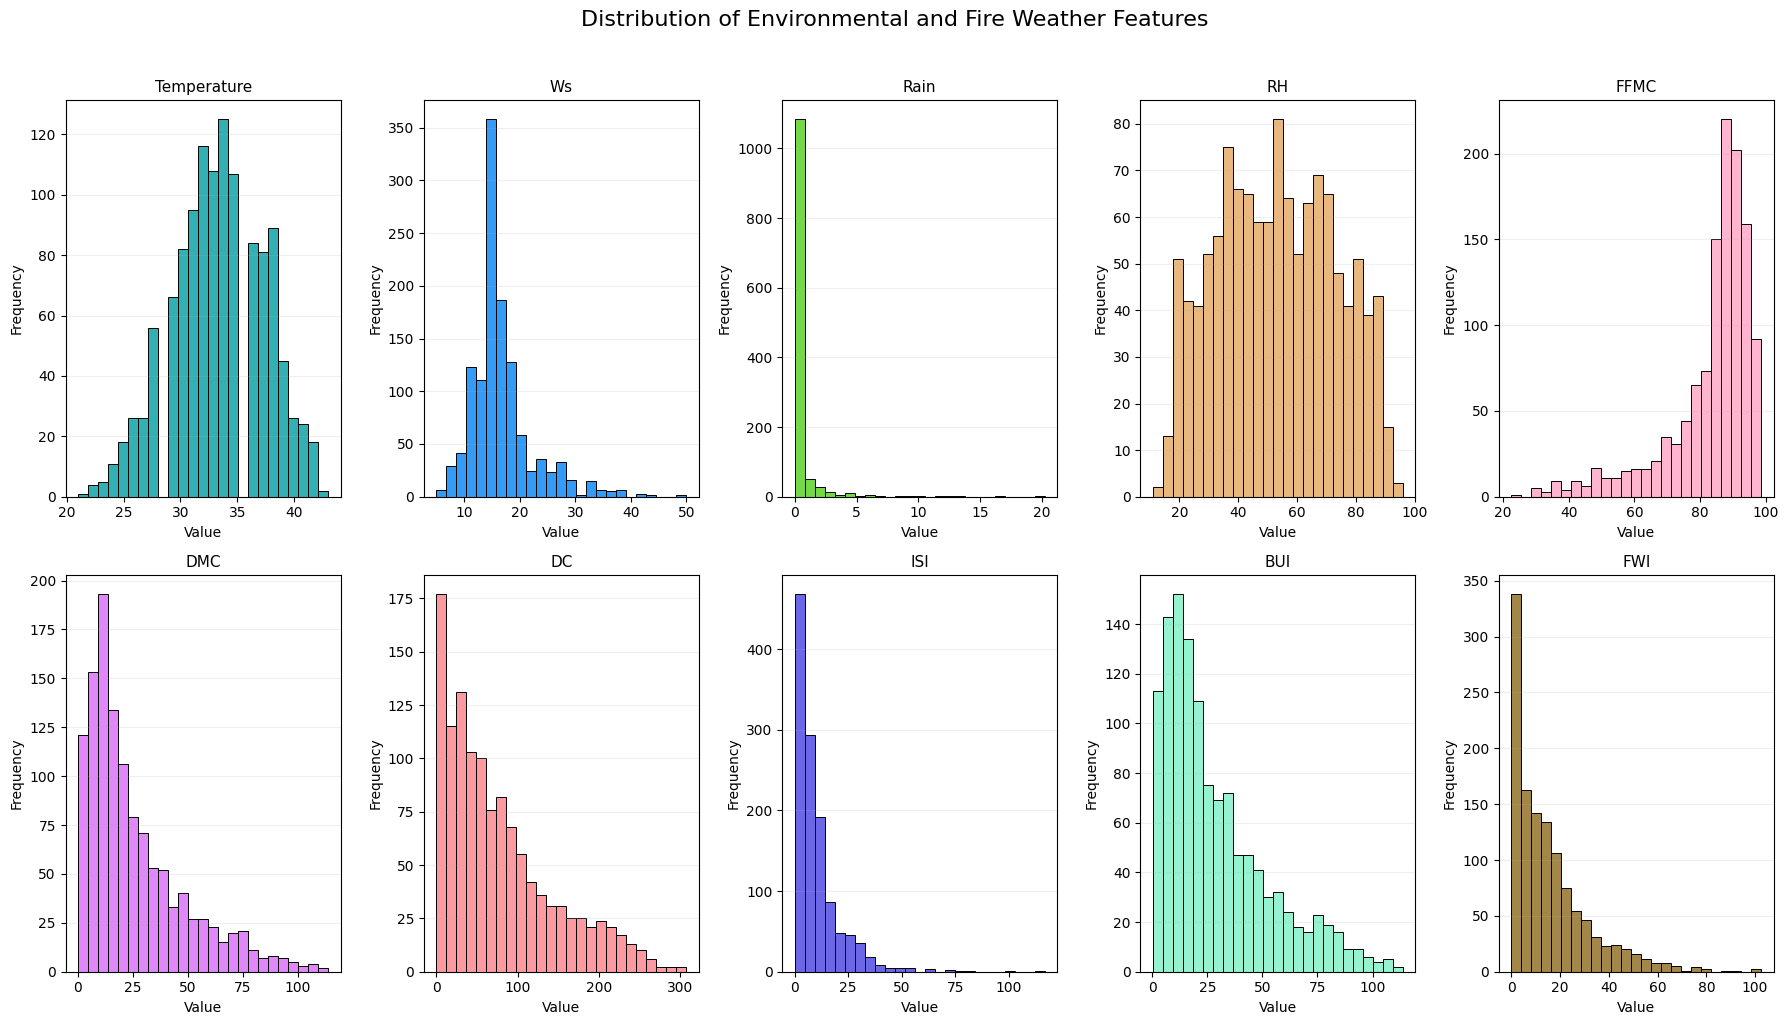

In [145]:
# ============================================================
# CELL 17: HISTOGRAMS OF NUMERICAL FEATURES
# ============================================================
# Histograms help us understand:
# - Distribution shape
# - Skewness
# - Concentration of observations
# - Potential extreme values
#
# Each feature is displayed using a different light color
# to make the plots visually distinct.
# ============================================================

# Light pastel colors for each feature
light_colors = [
    "#33B0B4",  # Light cyan
    "#349BF6",  # Light blue
    "#75D847",  # Light green
    "#E8B87E",  # Light orange
    "#FFB4D0",  # Light pink
    "#E087F9",  # Light purple
    "#FD9AA0",  # Light rose
    "#6B67E6",  # Light periwinkle
    "#95F3D2",  # Light mint
    "#A38749"   # Light yellow
]

# Create the histogram grid
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(18, 10)
)

# Plot each feature separately
for ax, feature, color in zip(
    axes.flatten(),
    numeric_columns,
    light_colors
):
    
    ax.hist(
        df[feature].dropna(),
        bins=25,
        color=color,
        edgecolor="black",
        linewidth=0.7
    )
    
    ax.set_title(feature, fontsize=11)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.grid(axis="y", alpha=0.2)

# Overall title
fig.suptitle(
    "Distribution of Environmental and Fire Weather Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### Conclusion

The environmental variables show different distribution patterns. Temperature and relative humidity are comparatively well distributed, while Rain, Wind Speed, ISI, DMC, DC, BUI, and FWI show noticeable right-skewness. Rainfall is particularly concentrated near zero with a few high values. These distributions will be considered during the preprocessing and model-development stages rather than removing extreme observations automatically.

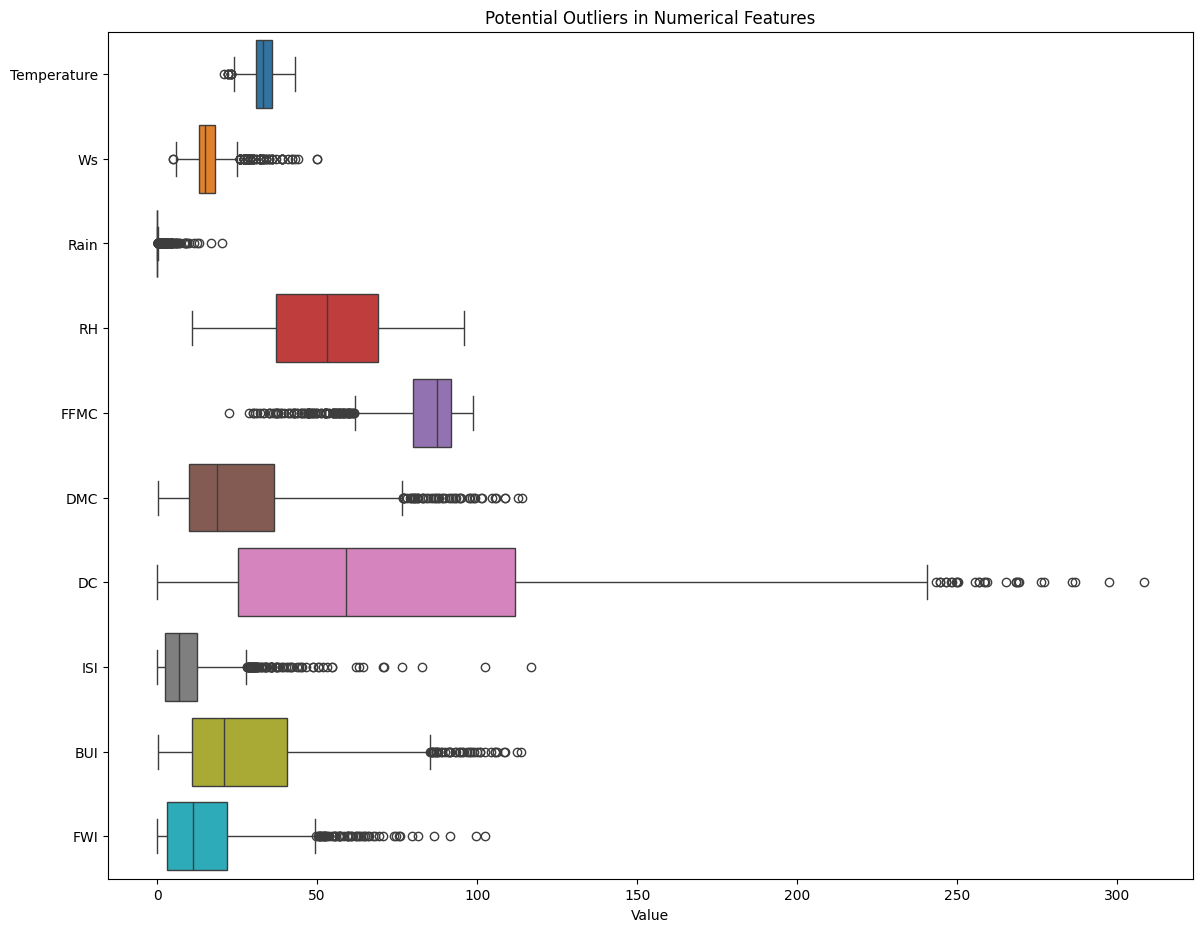

In [146]:
# ============================================================
# CELL 18: BOX PLOTS FOR OUTLIER INSPECTION
# ============================================================
# Boxplots are used to identify potential statistical outliers.
#
# We will NOT automatically delete these observations.
# They will first be evaluated from a domain perspective.
# ============================================================

plt.figure(figsize=(14, 11))

sns.boxplot(
    data=df[numeric_columns],
    orient="h"
)

plt.title("Potential Outliers in Numerical Features")
plt.xlabel("Value")

plt.show()

### Conclusion

The boxplots identify several potential statistical outliers, particularly in Rainfall, Wind Speed, ISI, and the Fire Weather Index variables. However, these observations are not automatically treated as errors because extreme environmental conditions can represent genuine fire-weather conditions. Therefore, the observations will be retained unless a clear domain or data-quality violation is identified.

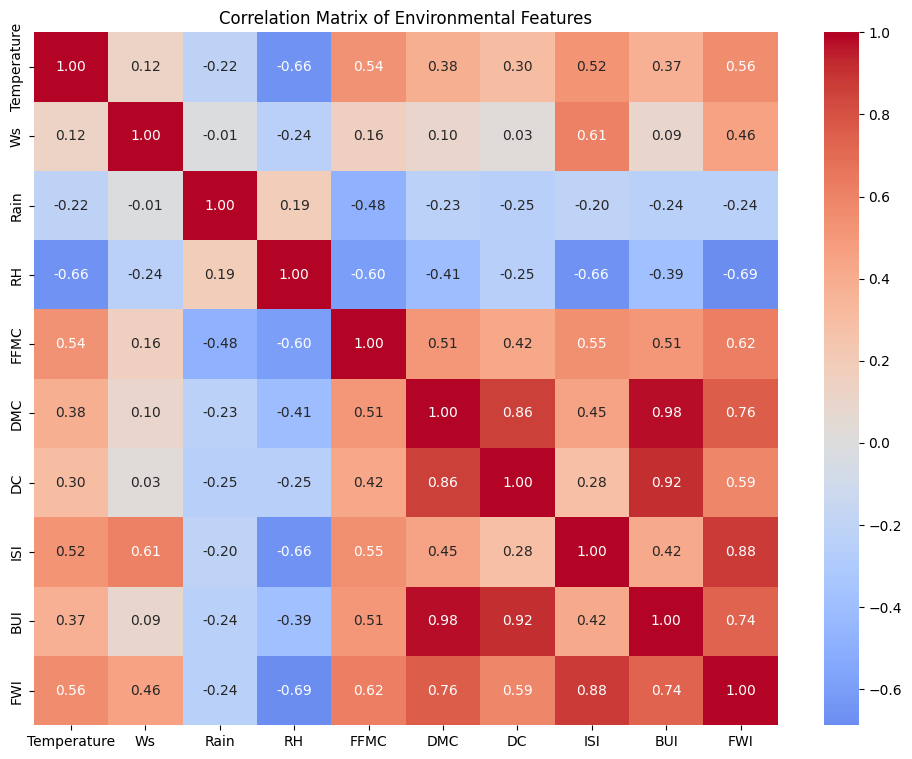

In [147]:
# ============================================================
# CELL 19: CORRELATION MATRIX
# ============================================================
# Examine relationships among environmental and FWI variables.
#
# Strong correlations are expected because several FWI variables
# are mathematically related to weather conditions.
# ============================================================

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Environmental Features")

plt.show()

### Conclusion

The correlation matrix shows strong relationships among the Fire Weather Index (FWI) components, particularly between FWI and ISI (0.879), DMC (0.760), and BUI (0.739). Relative humidity has a strong negative relationship with FWI (-0.687), while temperature has a moderate positive relationship (0.557). These correlations are expected because the FWI components are derived from related fire-weather conditions. The high correlations will be considered when interpreting model feature importance and SHAP explanations.

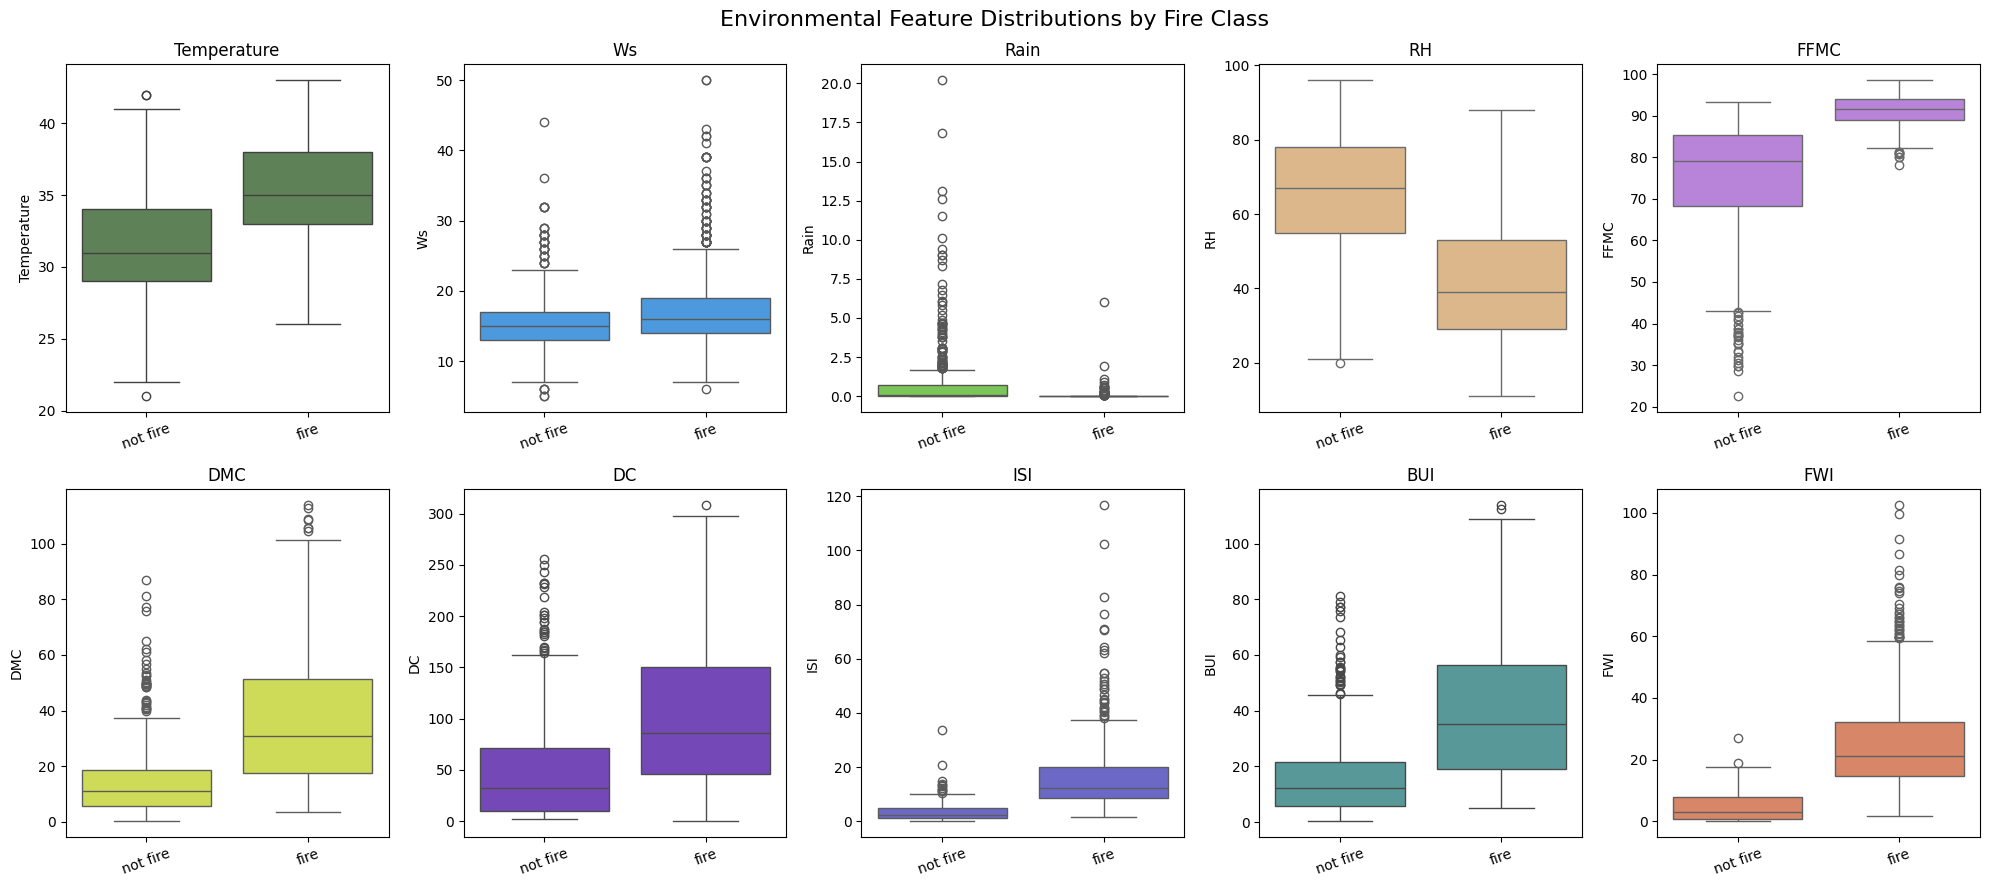

In [148]:
# ============================================================
# CELL 20: FEATURE DISTRIBUTIONS BY FIRE CLASS
# ============================================================
# Compare environmental conditions for Fire vs. No Fire
# observations.
# ============================================================
# Light pastel colors for each feature
light_colors = [
    "#5B8851",  # Light cyan
    "#349BF6",  # Light blue
    "#75D847",  # Light green
    "#E8B87E",  # Light orange
    "#BB76E7",  # Light pink
    "#DFF044",  # Light purple
    "#7135CB",  # Light rose
    "#5E5AD5",  # Light periwinkle
    "#4EA3A2",  # Light mint
    "#E97D56"   # Light yellow
]
fig, axes = plt.subplots(
    2, 5,
    figsize=(20,9)
)

for ax, feature, color in zip(axes.flatten(), numeric_columns, light_colors):

    sns.boxplot(
        data=df,
        x="Classes",
        y=feature,
        order=["not fire", "fire"],
        color=color,
        ax=ax
    )
    
    ax.set_title(feature)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.suptitle(
    "Environmental Feature Distributions by Fire Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Conclusion

The feature distributions show clear differences between fire and non-fire observations. Fire observations generally have higher temperature, wind speed, FFMC, DMC, DC, ISI, BUI, and FWI, while relative humidity and rainfall are lower. In particular, the mean FWI is substantially higher for fire observations (25.57) than for non-fire observations (4.54). These patterns indicate that the environmental variables contain useful predictive information for forest-fire risk classification.

In [149]:
# ============================================================
# CELL 21: CLASS-WISE FEATURE SUMMARY
# ============================================================
# Calculate the mean environmental conditions separately for
# Fire and No Fire observations.
# ============================================================

class_feature_summary = (
    df.groupby("Classes")[numeric_columns]
    .mean()
    .T
)

display(class_feature_summary)

Classes,fire,not fire
Temperature,35.352291,31.134021
Ws,17.758294,15.336770
Rain,0.035387,0.800515
RH,41.642970,65.195876
FFMC,91.367615,74.476117
DMC,37.229226,14.361168
DC,103.743918,50.276117
ISI,16.013270,3.260481
BUI,40.193207,16.358419
FWI,25.569194,4.542955


In [150]:
# ============================================================
# CELL 22: RENAME REGION/YEAR IDENTIFIER
# ============================================================
# The original final column contains region and year information.
# We rename it to make its purpose explicit.
# ============================================================

df = df.rename(
    columns={
        "Bejaia 2021": "Region_Period"
    }
)

print(df["Region_Period"].value_counts())

Region_Period
Bejaia 2021           122
Blida 2021            122
Bouira 2021           122
Tipaza2017            122
Setif 2021            122
Tiaret 2021           122
Sidi-Bel-Abass2012    122
Bejaia_2012           122
Tizi-Ouzou2021        122
Khenchela 2021        117
Name: count, dtype: int64


In [151]:
# ============================================================
# CELL 23: FIRE DISTRIBUTION ACROSS REGIONS/PERIODS
# ============================================================
# Examine how Fire vs. No Fire observations are distributed
# across the region/year groups.
# ============================================================

region_class_counts = pd.crosstab(
    df["Region_Period"],
    df["Classes"]
)

display(region_class_counts)

Classes,fire,not fire
Region_Period,,
Bejaia 2021,47,75
Bejaia_2012,59,63
Blida 2021,64,58
Bouira 2021,58,64
Khenchela 2021,75,42
Setif 2021,73,49
Sidi-Bel-Abass2012,79,43
Tiaret 2021,87,35
Tipaza2017,30,92


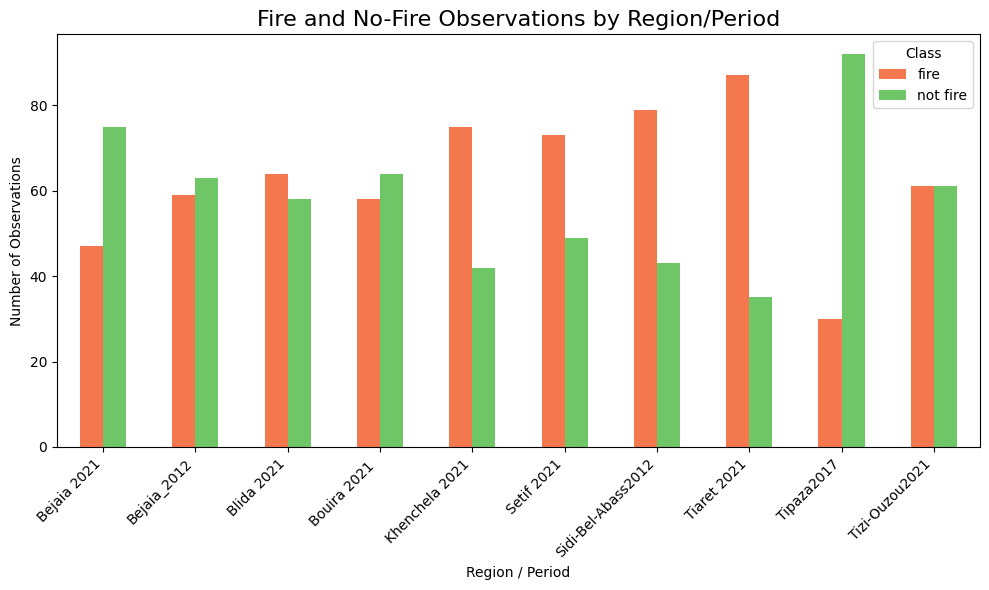

In [152]:
# ============================================================
# CELL 24: VISUALIZE FIRE DISTRIBUTION BY REGION/PERIOD
# ============================================================
# This bar chart shows the number of Fire and No Fire
# observations for each region/period.
#
# Green  -> No Fire
# Red    -> Fire
# ============================================================

region_class_counts.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#F4784E", "#6EC666"]
)

plt.title(
    "Fire and No-Fire Observations by Region/Period",
    fontsize=16
)

plt.xlabel("Region / Period")
plt.ylabel("Number of Observations")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Class"
)

plt.tight_layout()
plt.show()

### Conclusion

Fire occurrence varies across the region/period groups. Tiaret 2021 has the highest number of fire observations (87), while Tipaza 2017 has the highest number of non-fire observations (92). Tizi-Ouzou 2021 has an almost equal distribution between the two classes. This variation suggests that geographical and temporal conditions may influence fire occurrence. However, the region/period identifier will not be used directly as a primary predictive feature because it could encourage the model to learn location-specific patterns rather than general environmental relationships.

In [153]:
# ============================================================
# CELL 25: DATE-BASED FEATURE ENGINEERING
# ============================================================
# Extract useful temporal information from DATE.
#
# Month:
#   Captures broad seasonal differences.
#
# Day_of_Year:
#   Captures the progression through the fire season.
#
# The original DATE column will eventually be removed from
# the model feature set.
# ============================================================

df["Month"] = df["DATE"].dt.month
df["Day_of_Year"] = df["DATE"].dt.dayofyear

display(
    df[
        ["DATE", "Month", "Day_of_Year"]
    ].head()
)

,DATE,Month,Day_of_Year
0,2021-06-01,6,152
1,2021-06-02,6,153
2,2021-06-03,6,154
3,2021-06-04,6,155
4,2021-06-05,6,156


### Conclusion

The original date variable was converted into numerical temporal features, namely Month and Day_of_Year. These features preserve seasonal information that may influence fire risk while avoiding the use of the raw date as a direct model input.

In [154]:
# ============================================================
# CELL 26: DOMAIN-INFORMED FEATURE ENGINEERING
# ============================================================
# Create simple environmental features motivated by the
# physical interpretation of fire-weather conditions.
#
# 1. Dryness_Proxy:
#       Higher value = lower relative humidity.
#
# 2. Rain_Flag:
#       1 if measurable rainfall occurred, otherwise 0.
#
# 3. High_Temperature_Flag:
#       Indicates temperatures above 30°C.
#
# These features are created before the train/test split because
# they are deterministic transformations of individual rows and
# do not use information from the target or other observations.
# ============================================================

df["Dryness_Proxy"] = 100 - df["RH"]

df["Rain_Flag"] = (df["Rain"] > 0).astype(int)

df["High_Temperature_Flag"] = (
    df["Temperature"] >= 30
).astype(int)

display(
    df[
        [
            "Temperature",
            "RH",
            "Rain",
            "Dryness_Proxy",
            "Rain_Flag",
            "High_Temperature_Flag"
        ]
    ].head()
)

,Temperature,RH,Rain,Dryness_Proxy,Rain_Flag,High_Temperature_Flag
0,27,59,2.1,41,1,0
1,24,72,0.3,28,1,0
2,27,76,3.0,24,1,0
3,28,70,1.0,30,1,0
4,28,64,0.1,36,1,0


### Conclusion

Three domain-informed features were created to represent environmental conditions relevant to fire risk. Dryness_Proxy represents lower relative humidity as increasing dryness, Rain_Flag distinguishes rainy from non-rainy observations, and High_Temperature_Flag identifies relatively high-temperature conditions. These transformations provide additional interpretable representations of the original environmental variables.

## 5. Train / Validation / Test Split

To prevent information leakage, the dataset is divided into training,
validation, and test sets before model fitting.

The `Region_Period` identifier is retained temporarily for group-aware
splitting but is excluded from the predictive feature matrix.

The raw `DATE` and original `Classes` columns are also excluded from the
model because:
- `DATE` has already been transformed into Month and Day_of_Year.
- `Classes` is the original textual form of the target.

The final model will use environmental, Fire Weather Index, and engineered
temporal/environmental features.

In [155]:
# ============================================================
# CELL 27: DEFINE MODEL FEATURES AND TARGET
# ============================================================
# This cell defines:
# - X = predictor variables
# - y = binary target
# - groups = Region_Period used for group-aware splitting
#
# Region_Period is NOT used as a model feature.
# ============================================================

FEATURES = [
    "Temperature",
    "Ws",
    "Rain",
    "RH",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI",
    "Month",
    "Day_of_Year",
    "Dryness_Proxy",
    "Rain_Flag",
    "High_Temperature_Flag"
]

TARGET = "Fire"
GROUP = "Region_Period"

X = df[FEATURES].copy()
y = df[TARGET].copy()
groups = df[GROUP].copy()

print("Number of features:", len(FEATURES))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of groups:", groups.nunique())

print("\nFeatures:")
print(FEATURES)

Number of features: 15
Feature matrix shape: (1215, 15)
Target shape: (1215,)
Number of groups: 10

Features:
['Temperature', 'Ws', 'Rain', 'RH', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Month', 'Day_of_Year', 'Dryness_Proxy', 'Rain_Flag', 'High_Temperature_Flag']


In [156]:
# ============================================================
# CELL 28: VERIFY FEATURES AND TARGET
# ============================================================
# This is a final sanity check before splitting the data.
# It confirms that:
# - All required features exist
# - The target contains only 0 and 1
# - No missing values exist in X or y
# ============================================================

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())
print("Unique target values:", sorted(y.unique()))

display(X.head())
display(y.head())

Missing values in X: 0
Missing values in y: 0
Unique target values: [np.int64(0), np.int64(1)]


,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Month,Day_of_Year,Dryness_Proxy,Rain_Flag,High_Temperature_Flag
0,27,13,2.1,59,63.6,5.2,8.3,1.0,5.0,0.4,6,152,41,1,0
1,24,10,0.3,72,55.1,4.1,7.7,0.5,4.0,0.2,6,153,28,1,0
2,27,11,3.0,76,47.1,3.0,8.3,0.2,3.2,0.1,6,154,24,1,0
3,28,9,1.0,70,52.3,3.1,8.4,0.3,3.2,0.1,6,155,30,1,0
4,28,11,0.1,64,73.4,4.5,16.9,1.6,5.4,0.7,6,156,36,1,0


0    0
1    0
2    0
3    0
4    0
Name: Fire, dtype: int64

In [157]:
# ============================================================
# CELL 29: IMPORT GROUP-AWARE CROSS-VALIDATION SPLITTER
# ============================================================
# StratifiedGroupKFold provides two important properties:
#
# 1. Stratification:
#    Attempts to preserve the Fire/No Fire class distribution.
#
# 2. Group separation:
#    Keeps observations from the same Region_Period together.
#
# This helps reduce the risk of group-level data leakage.
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

RANDOM_STATE = 42

print("StratifiedGroupKFold imported successfully.")

StratifiedGroupKFold imported successfully.


## Why used Group-Aware Splitting?

The dataset contains observations belonging to specific **Region/Period groups**, such as Bejaia 2012, Bejaia 2021, Tiaret 2021, and Tipaza 2017. Multiple observations therefore come from the same geographical region and time period.

If we used a normal random train/test split, observations from the same Region/Period group could appear in both the training and test sets. The model could then learn patterns that are specific to a particular group, making the test performance appear better than its ability to generalize to an unseen group.

To reduce this risk, **StratifiedGroupKFold** was used for the dataset splitting.

### What does StratifiedGroupKFold do?

It combines two requirements:

1. **Group separation:**  
   Observations belonging to the same Region/Period group are kept together and are assigned to only one dataset split.

2. **Stratification:**  
   The splitter attempts to maintain a similar proportion of Fire and No Fire observations across the splits.

Therefore, the training, validation, and test sets contain different Region/Period groups while still maintaining a reasonably balanced target distribution.

### Why not use a normal random split?

A standard `train_test_split()` treats every row independently. In our dataset, this could place observations from the same Region/Period in both training and test sets, increasing the possibility of group-level leakage.

### Why not use only stratification?

A purely stratified split preserves the Fire/No Fire ratio but does not prevent observations from the same Region/Period group from being distributed across different sets.

### Why not use only GroupKFold?

`GroupKFold` keeps groups separated, but it does not specifically attempt to preserve the Fire/No Fire class distribution across folds.

### Why StratifiedGroupKFold is appropriate here

Our dataset has both:
- a **group structure** (Region/Period), and
- a **binary classification target** (Fire/No Fire).

Therefore, StratifiedGroupKFold provides a suitable compromise between preventing group-level leakage and maintaining reasonable class proportions.

The final test set is kept completely untouched during model training and hyperparameter tuning and is used only for final model evaluation.

In [158]:
# ============================================================
# CELL 30: CREATE THE TRAIN/TEST SPLIT
# ============================================================
# Five stratified group folds are created.
#
# The first fold is reserved as the final TEST SET.
#
# IMPORTANT:
# The test set will remain completely untouched until the final
# model comparison.
# ============================================================

sgkf_test = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_indices, test_indices = next(
    sgkf_test.split(X, y, groups=groups)
)

X_train_full = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train_full = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train_full = groups.iloc[train_indices].copy()
groups_test = groups.iloc[test_indices].copy()

print("Training set:", X_train_full.shape)
print("Test set    :", X_test.shape)

print("\nTraining groups:")
print(sorted(groups_train_full.unique()))

print("\nTest groups:")
print(sorted(groups_test.unique()))

Training set: (971, 15)
Test set    : (244, 15)

Training groups:
['Bejaia_2012', 'Bouira 2021 ', 'Khenchela 2021', 'Setif 2021', 'Sidi-Bel-Abass2012', 'Tiaret 2021', 'Tipaza2017', 'Tizi-Ouzou2021']

Test groups:
['Bejaia 2021', 'Blida 2021']


In [159]:
# ============================================================
# CELL 31: VALIDATE THE TRAIN/TEST SPLIT
# ============================================================
# This cell checks:
# - Number of observations
# - Class distribution
# - Percentage of Fire observations
# - Whether any groups overlap
# ============================================================

print("TRAINING SET")
print("-" * 50)
print("Observations:", len(X_train_full))
print("Fire:", y_train_full.sum())
print("No Fire:", (y_train_full == 0).sum())
print("Fire %:", round(y_train_full.mean() * 100, 2))

print("\nTEST SET")
print("-" * 50)
print("Observations:", len(X_test))
print("Fire:", y_test.sum())
print("No Fire:", (y_test == 0).sum())
print("Fire %:", round(y_test.mean() * 100, 2))

# Check group overlap
group_overlap = set(groups_train_full.unique()).intersection(
    set(groups_test.unique())
)

print("\nGroups appearing in BOTH train and test:")
print(group_overlap)

if len(group_overlap) == 0:
    print("✓ No group leakage detected.")
else:
    print("⚠ Group overlap detected!")

TRAINING SET
--------------------------------------------------
Observations: 971
Fire: 522
No Fire: 449
Fire %: 53.76

TEST SET
--------------------------------------------------
Observations: 244
Fire: 111
No Fire: 133
Fire %: 45.49

Groups appearing in BOTH train and test:
set()
✓ No group leakage detected.


In [160]:
# ============================================================
# CELL 32: CREATE THE TRAIN/VALIDATION SPLIT
# ============================================================
# The original training set is divided into:
#
# - Training set     → model fitting
# - Validation set   → model selection and tuning
#
# The final test set remains untouched.
#
# StratifiedGroupKFold is used again to prevent Region_Period
# groups from appearing in both training and validation sets.
# ============================================================

sgkf_val = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_indices_2, val_indices = next(
    sgkf_val.split(
        X_train_full,
        y_train_full,
        groups=groups_train_full
    )
)

X_train = X_train_full.iloc[train_indices_2].copy()
X_val = X_train_full.iloc[val_indices].copy()

y_train = y_train_full.iloc[train_indices_2].copy()
y_val = y_train_full.iloc[val_indices].copy()

groups_train = groups_train_full.iloc[train_indices_2].copy()
groups_val = groups_train_full.iloc[val_indices].copy()

print("Training set   :", X_train.shape)
print("Validation set :", X_val.shape)
print("Test set       :", X_test.shape)

Training set   : (727, 15)
Validation set : (244, 15)
Test set       : (244, 15)


In [161]:
# ============================================================
# CELL 33: FINAL TRAIN/VALIDATION/TEST SPLIT CHECK
# ============================================================
# Verify class distributions and group separation across all
# three datasets.
# ============================================================

def summarize_split(name, X_split, y_split, groups_split):
    """Display basic information about a dataset split."""
    
    print(f"\n{name}")
    print("-" * 50)
    print("Observations:", len(X_split))
    print("Features:", X_split.shape[1])
    print("Fire:", int(y_split.sum()))
    print("No Fire:", int((y_split == 0).sum()))
    print("Fire %:", round(y_split.mean() * 100, 2))
    print("Groups:", groups_split.nunique())


summarize_split(
    "TRAINING SET",
    X_train,
    y_train,
    groups_train
)

summarize_split(
    "VALIDATION SET",
    X_val,
    y_val,
    groups_val
)

summarize_split(
    "TEST SET",
    X_test,
    y_test,
    groups_test
)


TRAINING SET
--------------------------------------------------
Observations: 727
Features: 15
Fire: 402
No Fire: 325
Fire %: 55.3
Groups: 6

VALIDATION SET
--------------------------------------------------
Observations: 244
Features: 15
Fire: 120
No Fire: 124
Fire %: 49.18
Groups: 2

TEST SET
--------------------------------------------------
Observations: 244
Features: 15
Fire: 111
No Fire: 133
Fire %: 45.49
Groups: 2


In [162]:
# ============================================================
# CELL 34: VERIFY NO GROUP OVERLAP
# ============================================================
# A group must belong to only one of the three datasets.
# This is an important leakage-prevention check.
# ============================================================

train_groups = set(groups_train.unique())
val_groups = set(groups_val.unique())
test_groups = set(groups_test.unique())

train_val_overlap = train_groups.intersection(val_groups)
train_test_overlap = train_groups.intersection(test_groups)
val_test_overlap = val_groups.intersection(test_groups)

print("Train ∩ Validation:", train_val_overlap)
print("Train ∩ Test      :", train_test_overlap)
print("Validation ∩ Test :", val_test_overlap)

if not train_val_overlap and not train_test_overlap and not val_test_overlap:
    print("\n✓ All Region_Period groups are completely separated.")
else:
    print("\n⚠ Group overlap detected. Investigate before modeling.")

Train ∩ Validation: set()
Train ∩ Test      : set()
Validation ∩ Test : set()

✓ All Region_Period groups are completely separated.


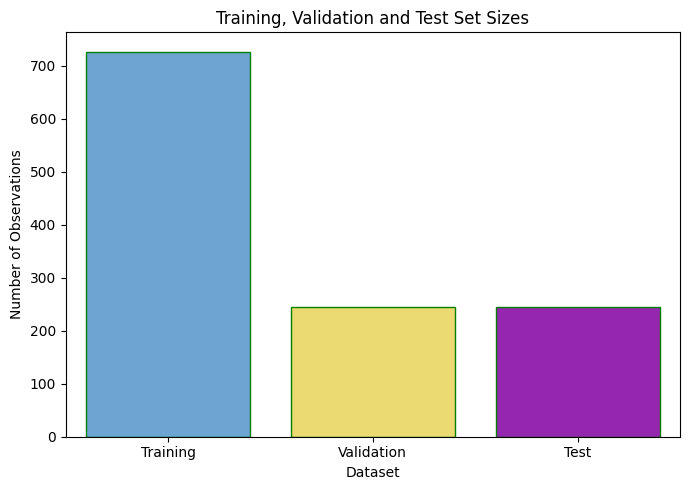

In [163]:
# ============================================================
# CELL 35: VISUALIZE DATASET SPLIT SIZES
# ============================================================
# Shows the number of observations assigned to:
# - Training
# - Validation
# - Test
# ============================================================

split_sizes = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Observations": [
        len(X_train),
        len(X_val),
        len(X_test)
    ]
})

plt.figure(figsize=(7, 5))

sns.barplot(
    data=split_sizes,
    x="Dataset",
    y="Observations",
    hue="Dataset",
    palette=["#5BA7E2", "#FFE75E", "#A310C4"],
    edgecolor="green",
    legend=False
)

plt.title("Training, Validation and Test Set Sizes")
plt.xlabel("Dataset")
plt.ylabel("Number of Observations")

plt.tight_layout()
plt.show()

### Conclusion

The dataset was divided into 727 training observations (59.8%), 244 validation observations (20.1%), and 244 test observations (20.1%). The fire proportion is 55.30% in the training set, 49.18% in the validation set, and 45.49% in the test set. Although the class proportions vary moderately across the splits, both classes remain sufficiently represented in each set. The group-aware split also keeps the Region/Period groups separated, reducing the risk of group-level data leakage. The test set is reserved exclusively for final model evaluation.

## 6. Leakage-Safe Preprocessing

A preprocessing pipeline is used to ensure that transformations are learned
only from the training data.

The predictive features are all numerical, so the numerical preprocessing
pipeline consists of:

- Median imputation for robustness against possible missing values.
- Standard scaling using `StandardScaler`.

Although tree-based models do not require feature scaling, a consistent
preprocessing pipeline is maintained across the model-development workflow.
Scaling is also useful for models such as Logistic Regression that may be
used as a meta-learner in the stacking ensemble.

The preprocessing object is fitted only on the training set. The validation
and test sets are transformed using the already-fitted preprocessing object.
This prevents information from the validation or test sets from influencing
the learned preprocessing parameters.

In [164]:
# ============================================================
# CELL 36: IMPORT PREPROCESSING COMPONENTS
# ============================================================
# This cell imports the tools required to construct a
# leakage-safe numerical preprocessing pipeline.
#
# SimpleImputer:
#     Handles missing numerical values if they occur.
#
# StandardScaler:
#     Standardizes numerical features.
#
# Pipeline:
#     Combines preprocessing operations into one reproducible
#     sequence.
#
# ColumnTransformer:
#     Allows different preprocessing to be applied to different
#     groups of columns.
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Preprocessing libraries imported successfully.")

Preprocessing libraries imported successfully.


In [165]:
# ============================================================
# CELL 37: DEFINE NUMERICAL FEATURES
# ============================================================
# All 15 predictive variables are numerical.
#
# These are the features that will enter the ML pipeline.
# Region_Period, DATE, and Classes are intentionally excluded.
# ============================================================

numeric_features = FEATURES.copy()

print("Number of numerical features:", len(numeric_features))
print("\nNumerical features:")
for feature in numeric_features:
    print("-", feature)

Number of numerical features: 15

Numerical features:
- Temperature
- Ws
- Rain
- RH
- FFMC
- DMC
- DC
- ISI
- BUI
- FWI
- Month
- Day_of_Year
- Dryness_Proxy
- Rain_Flag
- High_Temperature_Flag


In [166]:
# ============================================================
# CELL 38: BUILD NUMERICAL PREPROCESSING PIPELINE
# ============================================================
# The pipeline performs two operations:
#
# 1. Median imputation
#    Missing values are replaced using the median calculated
#    from the training data.
#
# 2. Standard scaling
#    Each feature is transformed to approximately:
#       mean = 0
#       standard deviation = 1
#
# These operations will be learned ONLY from X_train.
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

print("Numerical preprocessing pipeline created.")

Numerical preprocessing pipeline created.


In [167]:
# ============================================================
# CELL 39: BUILD COMPLETE PREPROCESSOR
# ============================================================
# ColumnTransformer applies the numerical preprocessing pipeline
# to all model features.
#
# Currently, all predictive features are numerical.
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        )
    ],
    remainder="drop"
)

print("Complete preprocessing pipeline created.")

Complete preprocessing pipeline created.


In [168]:
# ============================================================
# CELL 40: FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================
# IMPORTANT:
# The preprocessor learns imputation values and scaling
# parameters ONLY from X_train.
#
# X_val and X_test are NOT used during fitting.
# ============================================================

preprocessor.fit(X_train)

print("Preprocessor fitted using training data only.")

Preprocessor fitted using training data only.


In [169]:
# ============================================================
# CELL 41: TRANSFORM ALL DATA SPLITS
# ============================================================
# The already-fitted preprocessor is now used to transform:
#
# - Training data
# - Validation data
# - Test data
#
# No fitting is performed on validation or test data.
# ============================================================

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape   :", X_train_processed.shape)
print("Validation processed shape :", X_val_processed.shape)
print("Test processed shape       :", X_test_processed.shape)

Training processed shape   : (727, 15)
Validation processed shape : (244, 15)
Test processed shape       : (244, 15)


In [170]:
# ============================================================
# CELL 42: VERIFY FEATURE SCALING
# ============================================================
# Check the mean and standard deviation of the processed
# training features.
#
# StandardScaler should produce values close to:
#     Mean = 0
#     Standard deviation = 1
#
# The validation and test data are NOT expected to have exactly
# mean 0 and standard deviation 1 because the scaler was fitted
# only on the training data.
# ============================================================

processed_train_df = pd.DataFrame(
    X_train_processed,
    columns=numeric_features
)

scaling_check = pd.DataFrame({
    "Mean": processed_train_df.mean(),
    "Std": processed_train_df.std()
})

display(scaling_check)

,Mean,Std
Temperature,-7.330221e-16,1.000688
Ws,-1.563780e-16,1.000688
Rain,-6.841539e-17,1.000688
RH,4.886814e-18,1.000688
FFMC,-3.811715e-16,1.000688
DMC,6.841539e-17,1.000688
DC,8.796265e-17,1.000688
ISI,-4.886814e-17,1.000688
BUI,7.085880e-17,1.000688
FWI,-4.886814e-17,1.000688


In [171]:
# ============================================================
# CELL 43: VERIFY PROCESSED DATA
# ============================================================
# Confirm that the preprocessing stage has produced valid
# numerical data without missing values.
# ============================================================

print(
    "Missing values in processed training data:",
    np.isnan(X_train_processed).sum()
)

print(
    "Missing values in processed validation data:",
    np.isnan(X_val_processed).sum()
)

print(
    "Missing values in processed test data:",
    np.isnan(X_test_processed).sum()
)

Missing values in processed training data: 0
Missing values in processed validation data: 0
Missing values in processed test data: 0


### Conclusion

A leakage-safe preprocessing pipeline was constructed for the 15 numerical
predictive features. Median imputation and standardization were included
within the pipeline, although the current dataset contains no missing values.
The preprocessing parameters were fitted exclusively on the training set and
then applied to the validation and test sets. This prevents information from
the evaluation data from influencing preprocessing and supports a
reproducible machine learning workflow.

## 7. Baseline Model — Decision Tree

A Decision Tree classifier is used as the baseline model.

The baseline provides a simple reference against which the more advanced
ensemble models can be compared.

The model is evaluated on the validation set using:

- ROC-AUC
- Precision
- Recall
- F1-score
- Confusion Matrix

The validation set is used for this intermediate evaluation. The test set
remains untouched until the final comparison of all models.

In [172]:
# ============================================================
# CELL 44: IMPORT BASELINE MODEL AND EVALUATION METRICS
# ============================================================
# This cell imports:
#
# DecisionTreeClassifier:
#     Our baseline classification model.
#
# Evaluation metrics:
#     ROC-AUC, precision, recall, F1-score, and confusion matrix.
# ============================================================

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Decision Tree and evaluation metrics imported successfully.")

Decision Tree and evaluation metrics imported successfully.


In [173]:
# ============================================================
# CELL 45: CREATE LEAKAGE-SAFE DECISION TREE PIPELINE
# ============================================================
# The pipeline combines:
#
# 1. Numerical preprocessing
# 2. Decision Tree classifier
#
# When .fit() is called, preprocessing is fitted ONLY on the
# training data passed to the pipeline.
# ============================================================

baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline(
                            steps=[
                                (
                                    "imputer",
                                    SimpleImputer(strategy="median")
                                ),
                                (
                                    "scaler",
                                    StandardScaler()
                                )
                            ]
                        ),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [174]:
# ============================================================
# CELL 46: TRAIN THE DECISION TREE BASELINE
# ============================================================
# The baseline pipeline is fitted ONLY on the training data.
#
# The validation and test sets are not used during training.
# ============================================================

baseline_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree baseline trained successfully.")

Decision Tree baseline trained successfully.


In [175]:
# ============================================================
# CELL 47: GENERATE BASELINE VALIDATION PREDICTIONS
# ============================================================
# Generate:
#
# y_val_pred:
#     Predicted class (0 or 1)
#
# y_val_proba:
#     Probability of the positive class (Fire)
#
# ROC-AUC requires probability/score information rather than
# only the final predicted class.
# ============================================================

y_val_pred_baseline = baseline_pipeline.predict(X_val)

y_val_proba_baseline = baseline_pipeline.predict_proba(X_val)[:, 1]

print("Validation predictions generated.")
print("Number of predictions:", len(y_val_pred_baseline))

Validation predictions generated.
Number of predictions: 244


In [176]:
# ============================================================
# CELL 48: EVALUATE DECISION TREE BASELINE
# ============================================================
# Calculate the main classification metrics required by the
# assignment.
#
# ROC-AUC:
#     Measures ranking ability across classification thresholds.
#
# Precision:
#     Of observations predicted as Fire, how many were actually Fire?
#
# Recall:
#     Of actual Fire observations, how many did the model detect?
#
# F1:
#     Harmonic mean of precision and recall.
# ============================================================

baseline_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_baseline
)

baseline_precision = precision_score(
    y_val,
    y_val_pred_baseline,
    zero_division=0
)

baseline_recall = recall_score(
    y_val,
    y_val_pred_baseline,
    zero_division=0
)

baseline_f1 = f1_score(
    y_val,
    y_val_pred_baseline,
    zero_division=0
)

baseline_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "ROC-AUC": [baseline_roc_auc],
    "Precision": [baseline_precision],
    "Recall": [baseline_recall],
    "F1": [baseline_f1]
})

display(
    baseline_results.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Decision Tree,0.8296,0.9647,0.6833,0.8


In [177]:
# ============================================================
# CELL 49: BASELINE CLASSIFICATION REPORT
# ============================================================
# This provides class-specific precision, recall and F1-score.
#
# Class 0 = No Fire
# Class 1 = Fire
# ============================================================

print(
    classification_report(
        y_val,
        y_val_pred_baseline,
        target_names=["No Fire", "Fire"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fire       0.76      0.98      0.86       124
        Fire       0.96      0.68      0.80       120

    accuracy                           0.83       244
   macro avg       0.86      0.83      0.83       244
weighted avg       0.86      0.83      0.83       244



<Figure size 700x600 with 0 Axes>

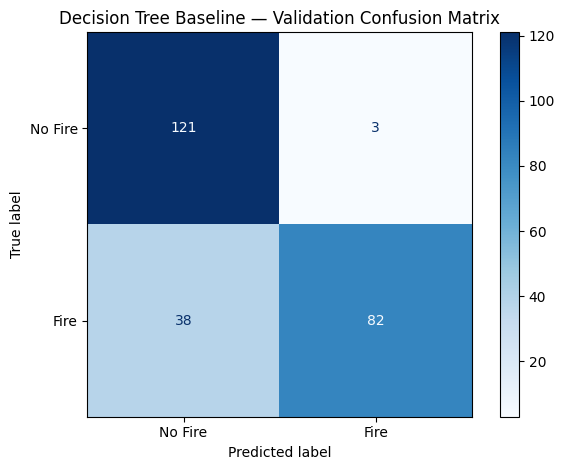

In [178]:
# ============================================================
# CELL 50: BASELINE CONFUSION MATRIX
# ============================================================
# The confusion matrix shows:
#
# True Negative  -> Correctly predicted No Fire
# False Positive -> No Fire predicted as Fire
# False Negative -> Fire predicted as No Fire
# True Positive  -> Correctly predicted Fire
#
# False negatives are especially important in this application
# because failing to identify a real fire can have serious
# consequences.
# ============================================================

cm_baseline = confusion_matrix(
    y_val,
    y_val_pred_baseline
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=["No Fire", "Fire"]
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Decision Tree Baseline — Validation Confusion Matrix")

plt.tight_layout()
plt.show()

### Conclusion

The Decision Tree correctly classifies 121 No Fire observations and 82 Fire
observations. It produces 3 false positives but 38 false negatives. The
relatively high number of missed Fire observations is important because false
negatives are particularly costly in an early-warning forest-fire
application. This provides a useful baseline for evaluating the ensemble
models.

### Baseline Interpretation

The Decision Tree provides the initial performance benchmark for the
forest-fire classification task. Its validation ROC-AUC, precision, recall,
and F1-score will serve as reference values for evaluating whether the
Random Forest, XGBoost, and Stacking ensembles provide a meaningful
improvement.

The confusion matrix is particularly important because false negatives
represent fire events that the model fails to identify. In a real
early-warning application, these errors could be more consequential than
false positives, although excessive false positives could also lead to
unnecessary allocation of monitoring and response resources.

In [179]:
# ============================================================
# CELL 51: EXTRACT BASELINE CONFUSION MATRIX VALUES
# ============================================================
# Store TN, FP, FN and TP separately so that they can be used
# later in the results table and report.
# ============================================================

tn_baseline, fp_baseline, fn_baseline, tp_baseline = cm_baseline.ravel()

print("True Negative :", tn_baseline)
print("False Positive:", fp_baseline)
print("False Negative:", fn_baseline)
print("True Positive :", tp_baseline)

True Negative : 121
False Positive: 3
False Negative: 38
True Positive : 82


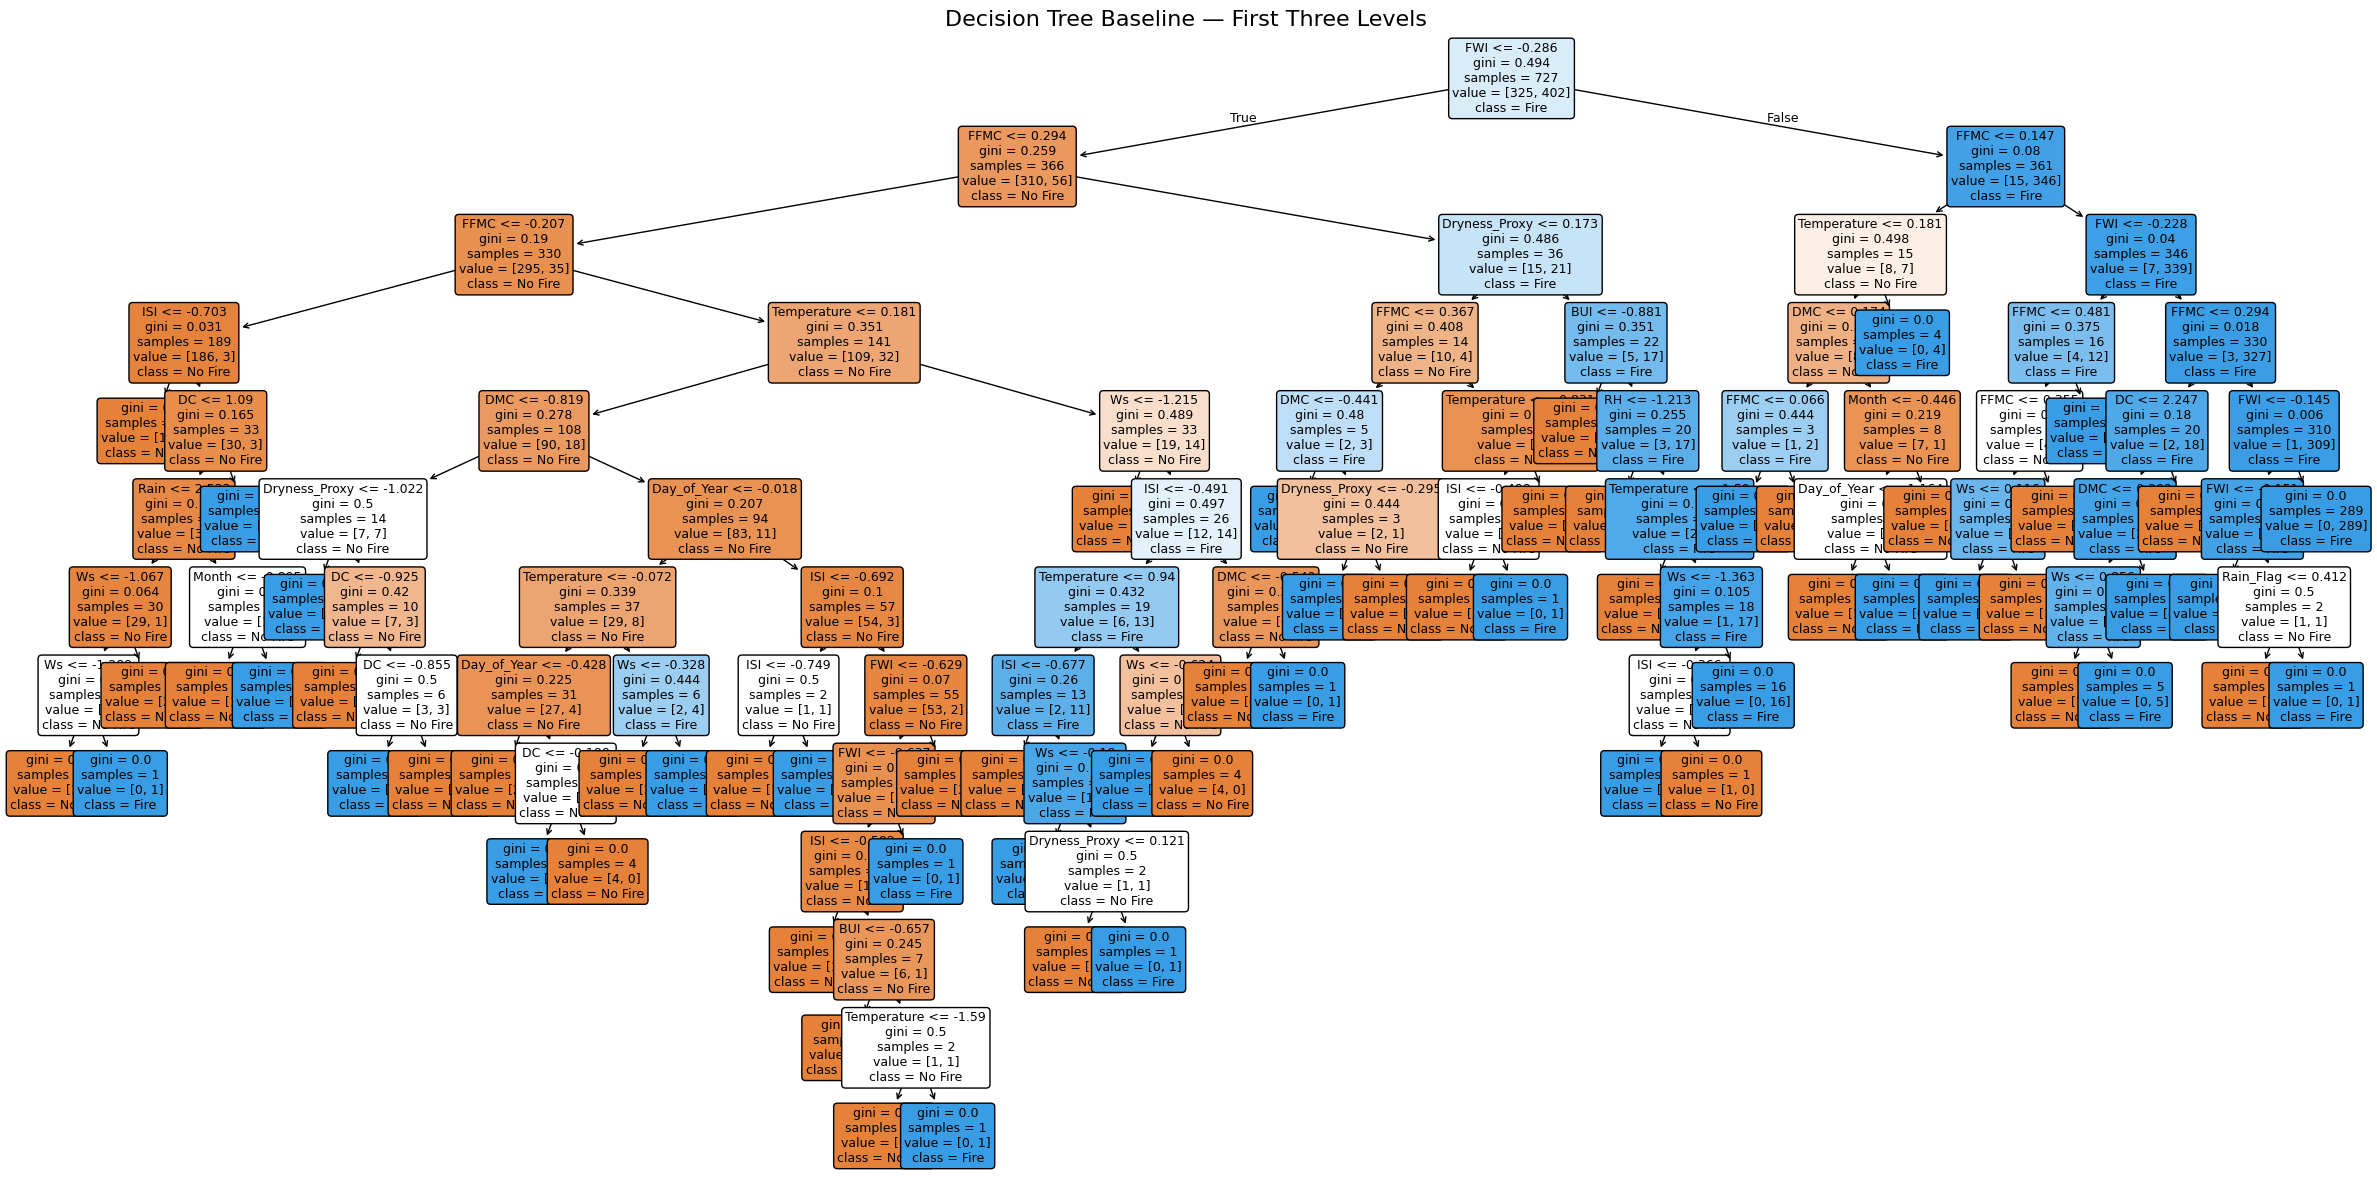

In [180]:
# ============================================================
# CELL 52: VISUALIZE THE DECISION TREE
# ============================================================
# This cell visualizes the first few levels of the trained
# Decision Tree.
#
# The complete tree may contain many branches, so we limit
# max_depth in the visualization only.
#
# IMPORTANT:
# This does NOT change the trained model.
# It only controls how much of the tree is displayed.
# ============================================================

from sklearn.tree import plot_tree

# Extract the trained Decision Tree from the pipeline
decision_tree_model = baseline_pipeline.named_steps["model"]

# Obtain the feature names after preprocessing
tree_feature_names = numeric_features

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=tree_feature_names,
    class_names=["No Fire", "Fire"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree Baseline — First Three Levels",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Conclusion

The Decision Tree learns a hierarchical set of rules to distinguish Fire from
No Fire observations. The upper levels of the tree rely strongly on Fire
Weather Index (FWI), FFMC, Dryness Proxy, Temperature, ISI, DMC, and BUI,
which is consistent with the patterns observed during exploratory data
analysis.

FWI appears at the root of the tree, indicating that it provides a strong
initial separation between the two classes. Subsequent branches use
additional fire-weather and environmental variables to refine the
classification.

The complete tree contains many branches and becomes difficult to interpret
visually. Therefore, the first three levels are used as the main
visualization, while the complete tree is retained as a supplementary
inspection of the trained baseline model.

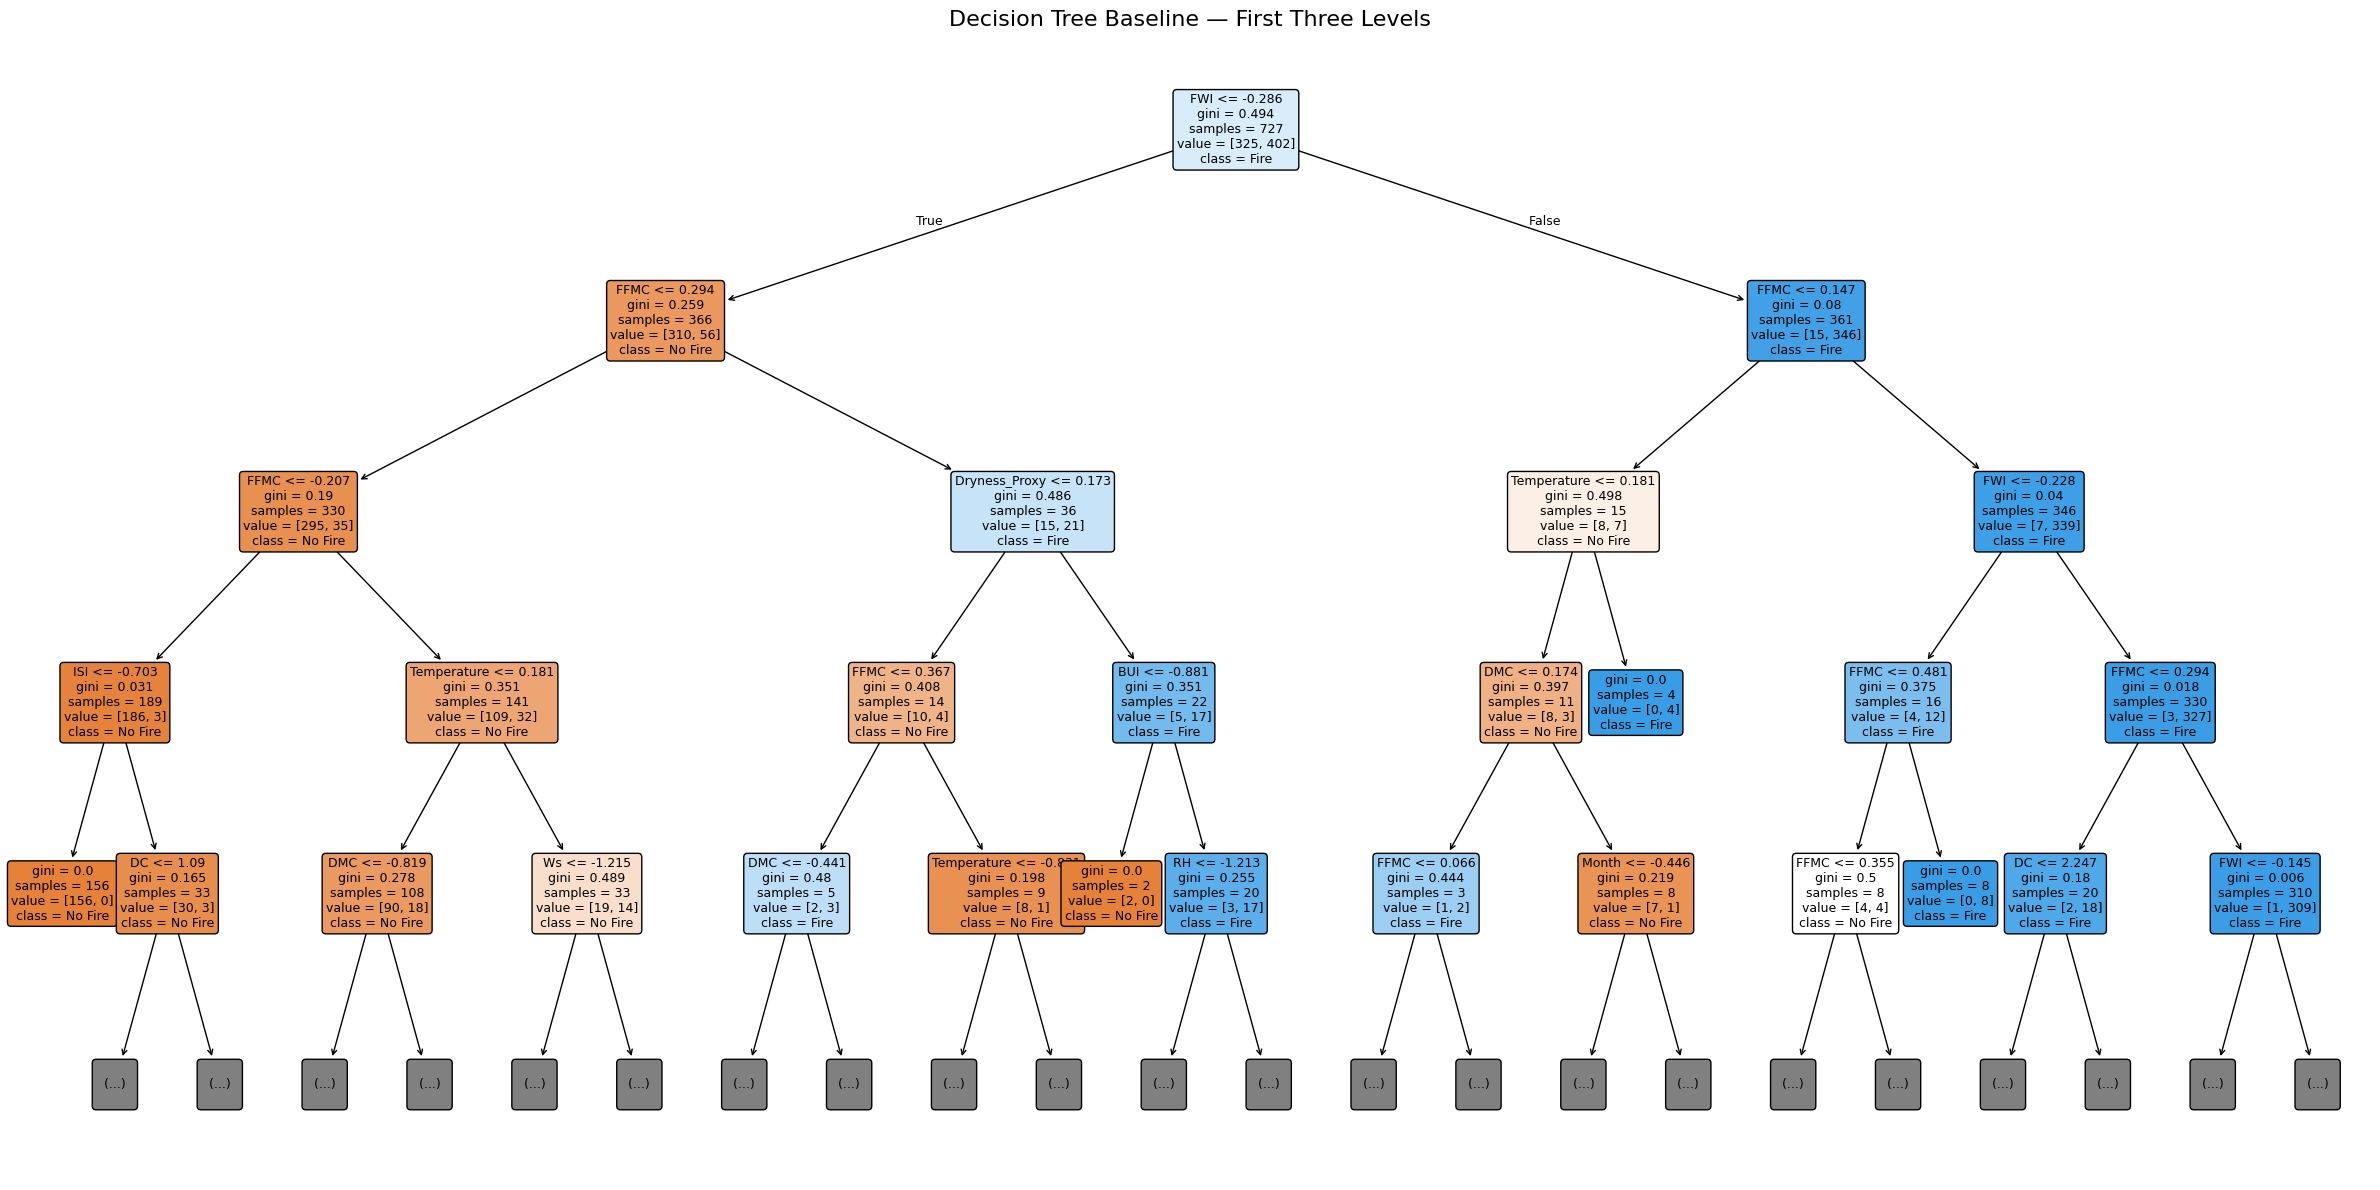

In [181]:
# for report and understanding we will visualize tree with max depth of 4
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=tree_feature_names,
    class_names=["No Fire", "Fire"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title(
    "Decision Tree Baseline — First Three Levels",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 8. Bagging Ensemble — Random Forest

Random Forest is used as the bagging ensemble model required by the
challenge.

A Random Forest combines multiple Decision Trees. Each tree is trained using
randomized samples and feature selections, and their predictions are
aggregated to produce the final prediction.

Compared with a single Decision Tree, Random Forest generally reduces
variance and provides more stable predictions.

Hyperparameters are tuned using 5-fold StratifiedGroupKFold cross-validation
on the training set. The Region_Period groups are kept separate during
cross-validation to reduce group-level data leakage.

The validation set is used only for intermediate evaluation, while the
test set remains untouched until the final model comparison.

In [182]:
# ============================================================
# CELL 53: IMPORT RANDOM FOREST AND TUNING TOOLS
# ============================================================
# RandomForestClassifier:
#     Implements the bagging ensemble.
#
# RandomizedSearchCV:
#     Searches for a good combination of Random Forest
#     hyperparameters using cross-validation.
#
# StratifiedGroupKFold:
#     Maintains group separation while attempting to preserve
#     the Fire / No Fire class distribution.
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedGroupKFold

print("Random Forest libraries imported successfully.")

Random Forest libraries imported successfully.


In [183]:
# ============================================================
# CELL 54: CREATE GROUP-AWARE CROSS-VALIDATION
# ============================================================
# Five-fold StratifiedGroupKFold is used for hyperparameter
# tuning.
#
# Stratification:
#     Attempts to maintain the Fire / No Fire ratio.
#
# Grouping:
#     Keeps observations from the same Region_Period group
#     together within a fold.
#
# This prevents the same Region_Period group from contributing
# observations to both the training and validation portion of
# an individual CV fold.
# ============================================================

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-fold StratifiedGroupKFold created successfully.")

5-fold StratifiedGroupKFold created successfully.


In [184]:
# ============================================================
# CELL 55: CREATE RANDOM FOREST PIPELINE
# ============================================================
# The preprocessing and Random Forest are placed inside one
# Pipeline.
#
# This is important because during cross-validation, the
# preprocessing is fitted separately inside each training fold.
# Therefore, validation-fold information does not leak into
# preprocessing.
# ============================================================

rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline(
                            steps=[
                                (
                                    "imputer",
                                    SimpleImputer(strategy="median")
                                ),
                                (
                                    "scaler",
                                    StandardScaler()
                                )
                            ]
                        ),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [185]:
# ============================================================
# CELL 56: DEFINE RANDOM FOREST HYPERPARAMETER SEARCH SPACE
# ============================================================
# n_estimators:
#     Number of trees in the forest.
#
# max_depth:
#     Maximum depth of each tree.
#
# min_samples_split:
#     Minimum number of samples required to split an internal
#     node.
#
# min_samples_leaf:
#     Minimum number of samples required in a leaf node.
#
# max_features:
#     Number of features considered when looking for a split.
# ============================================================

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

print("Random Forest hyperparameter search space created.")

Random Forest hyperparameter search space created.


In [186]:
# ============================================================
# CELL 57: TUNE RANDOM FOREST USING CROSS-VALIDATION
# ============================================================
# RandomizedSearchCV tests 20 randomly selected combinations
# from the search space defined above.
#
# Each combination is evaluated using 5-fold
# StratifiedGroupKFold.
#
# ROC-AUC is used as the optimization metric.
#
# The groups argument ensures that Region_Period information
# is respected during cross-validation.
# ============================================================

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("Random Forest tuning completed successfully.")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest tuning completed successfully.


In [187]:
# ============================================================
# CELL 58: DISPLAY BEST RANDOM FOREST PARAMETERS
# ============================================================
# Display the configuration that achieved the highest mean
# cross-validation ROC-AUC.
# ============================================================

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest mean CV ROC-AUC:")
print(round(rf_search.best_score_, 4))

Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10}

Best mean CV ROC-AUC:
0.9707


In [188]:
# ============================================================
# CELL 59: EVALUATE RANDOM FOREST ON VALIDATION SET
# ============================================================
# The best Random Forest found during cross-validation is now
# evaluated on the separate validation set.
#
# The test set is NOT used here.
# ============================================================

best_rf = rf_search.best_estimator_

# Predicted class labels
y_val_pred_rf = best_rf.predict(X_val)

# Probability of the Fire class
y_val_proba_rf = best_rf.predict_proba(X_val)[:, 1]

print("Validation predictions generated successfully.")

Validation predictions generated successfully.


In [189]:
# ============================================================
# CELL 60: CALCULATE RANDOM FOREST VALIDATION METRICS
# ============================================================
# Metrics:
# - ROC-AUC
# - Precision
# - Recall
# - F1-score
# ============================================================

rf_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_rf
)

rf_precision = precision_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_val,
    y_val_pred_rf,
    zero_division=0
)

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "ROC-AUC": [rf_roc_auc],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "F1": [rf_f1]
})

display(
    rf_results.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Random Forest,0.9595,0.9625,0.6417,0.77


In [190]:
# ============================================================
# CELL 61: RANDOM FOREST CLASSIFICATION REPORT
# ============================================================
# Provides class-specific precision, recall and F1-score.
#
# Class 0 = No Fire
# Class 1 = Fire
# ============================================================

print(
    classification_report(
        y_val,
        y_val_pred_rf,
        target_names=["No Fire", "Fire"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fire       0.74      0.98      0.84       124
        Fire       0.96      0.64      0.77       120

    accuracy                           0.81       244
   macro avg       0.85      0.81      0.81       244
weighted avg       0.85      0.81      0.81       244



<Figure size 700x600 with 0 Axes>

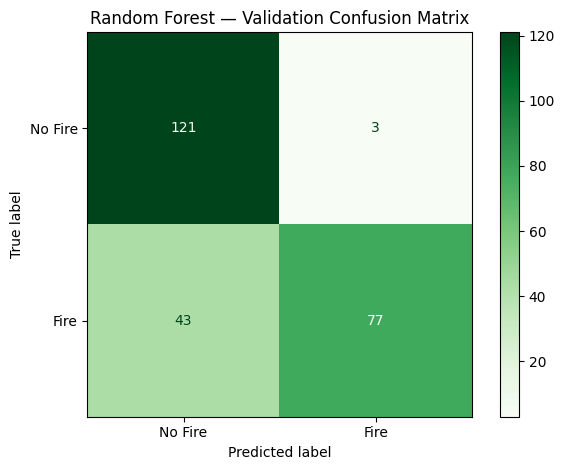

In [191]:
# ============================================================
# CELL 62: RANDOM FOREST CONFUSION MATRIX
# ============================================================
# Shows:
# - True Negatives
# - False Positives
# - False Negatives
# - True Positives
#
# False negatives are particularly important in a forest-fire
# early-warning context because they represent Fire cases that
# were incorrectly classified as No Fire.
# ============================================================

cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Fire", "Fire"]
)

disp.plot(
    cmap="Greens",
    values_format="d"
)

plt.title(
    "Random Forest — Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### Conclusion

The Random Forest correctly identifies most No Fire observations, while its
Fire-class recall is lower at 64.17%. This indicates that the model has high
precision (96.25%) but still misses some actual fire events. Since missed
fires are particularly important in an early-warning application, improving
Fire-class recall will remain an important consideration when comparing the
boosting and stacking ensembles.

In [192]:
# ============================================================
# CELL 63: COMPARE BASELINE AND RANDOM FOREST
# ============================================================
# Compare the Decision Tree baseline and Random Forest using
# exactly the same validation metrics.
# ============================================================

model_comparison = pd.concat(
    [
        baseline_results,
        rf_results
    ],
    ignore_index=True
)

display(
    model_comparison.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Decision Tree,0.8296,0.9647,0.6833,0.80
1,Random Forest,0.9595,0.9625,0.6417,0.77


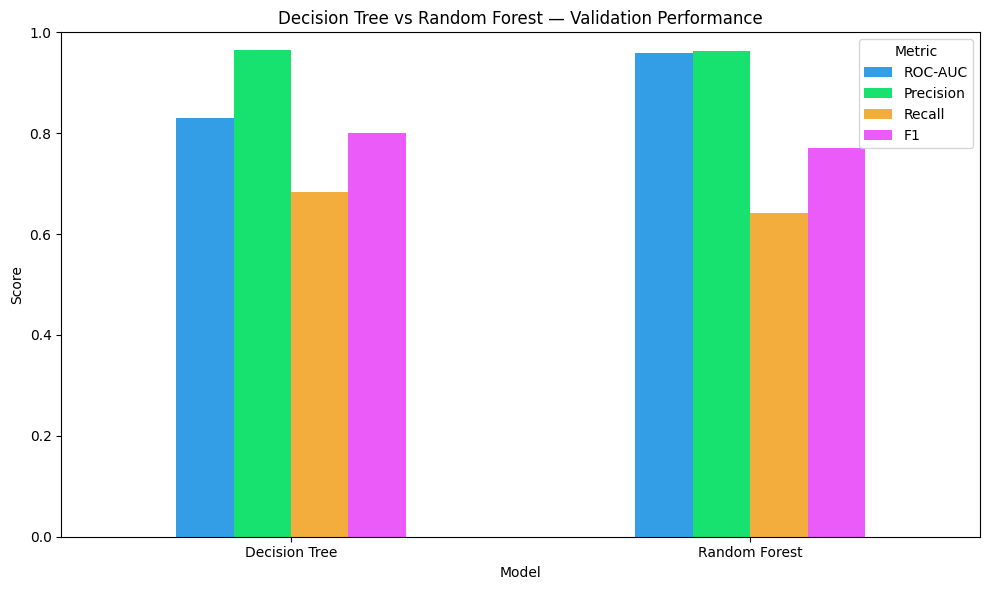

In [195]:
# ============================================================
# CELL 64: VISUALIZE MODEL PERFORMANCE
# ============================================================
# Compare Decision Tree and Random Forest across the four
# main validation metrics.
# ============================================================

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#339EE6", "#17E26F", "#F3AD3D", "#EA5BFA"]
)

plt.title("Decision Tree vs Random Forest — Validation Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Conclusion

The Random Forest substantially improves ROC-AUC from 0.8296 for the
Decision Tree to 0.9595, indicating much stronger overall discrimination.
However, the Decision Tree has slightly higher recall (0.6833) and F1-score
(0.80) than the Random Forest (0.6417 and 0.77). Therefore, the Random Forest
provides better ranking performance but does not improve every classification
metric over the baseline.

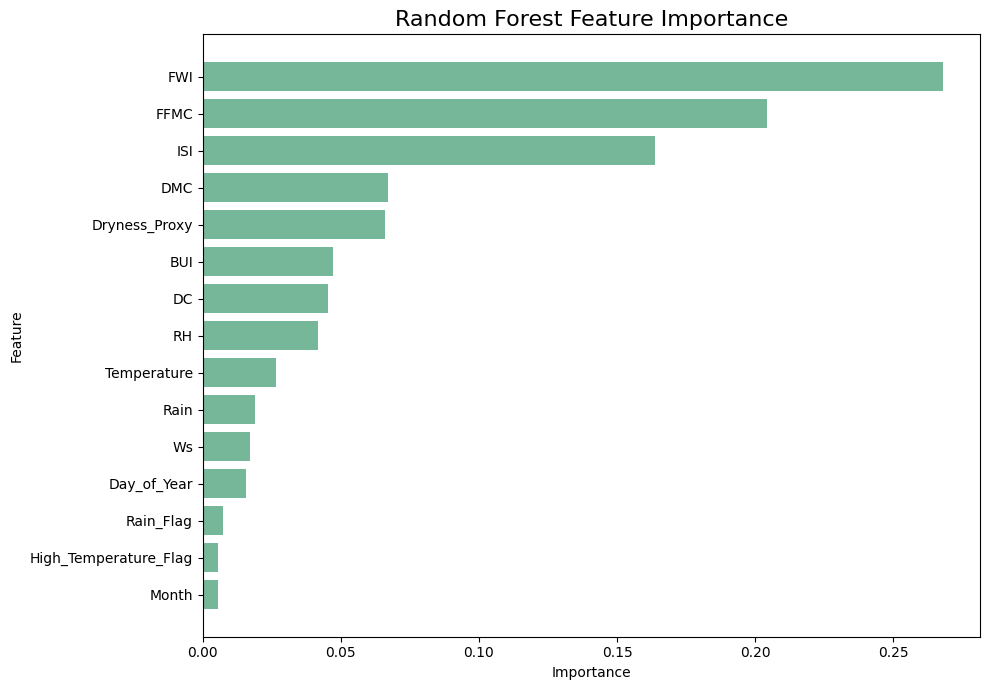

In [ ]:
# ============================================================
# CELL 65: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
# This visualization shows the features that contribute most
# to the Random Forest's decision-making.
#
# Feature importance is calculated from the trained Random
# Forest using the mean decrease in impurity.
# ============================================================

# Extract the trained Random Forest from the pipeline
rf_model = best_rf.named_steps["model"]

# Get feature importance values
rf_importances = rf_model.feature_importances_

# Create a DataFrame for easier visualization
rf_feature_importance = pd.DataFrame({
    "Feature": numeric_features,
    "Importance": rf_importances
})

# Sort from least to most important
rf_feature_importance = rf_feature_importance.sort_values(
    "Importance",
    ascending=True
)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"],
    color="#75B798"
)

plt.title(
    "Random Forest Feature Importance",
    fontsize=16
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Conclusion

The Random Forest feature-importance analysis shows that the model relies
more heavily on some environmental and Fire Weather Index variables than
others. The importance rankings provide an initial interpretation of which
features contribute most to the ensemble's tree-splitting decisions.

These rankings will be compared with the later SHAP analysis, which will
provide a more detailed explanation of both global feature influence and
individual predictions. Feature importance should not be interpreted as
causal evidence.

## 9. Boosting Ensemble — XGBoost

XGBoost is used as the boosting ensemble required by the challenge.

Unlike Random Forest, which builds trees independently and combines their
predictions, boosting builds trees sequentially. Each new tree focuses on
reducing the errors made by the existing ensemble.

XGBoost is tuned using 5-fold StratifiedGroupKFold cross-validation on the
training data. The Region_Period groups are kept separated during
cross-validation to reduce group-level leakage.

ROC-AUC is used as the hyperparameter-selection metric. The validation set
is reserved for intermediate evaluation, while the test set remains
untouched until final model comparison.

In [198]:
# ============================================================
# CELL 66: IMPORT XGBOOST
# ============================================================
# XGBClassifier is the classification implementation of XGBoost.
# ============================================================

from xgboost import XGBClassifier

print("XGBoost imported successfully.")

XGBoost imported successfully.


In [199]:
# ============================================================
# CELL 67: CREATE XGBOOST PIPELINE
# ============================================================
# The preprocessing and XGBoost model are combined into one
# pipeline.
#
# During cross-validation, preprocessing is fitted separately
# within each training fold, preventing preprocessing leakage.
# ============================================================

xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline(
                            steps=[
                                (
                                    "imputer",
                                    SimpleImputer(strategy="median")
                                ),
                                (
                                    "scaler",
                                    StandardScaler()
                                )
                            ]
                        ),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=2
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")

XGBoost pipeline created successfully.


In [200]:
# ============================================================
# CELL 68: DEFINE XGBOOST HYPERPARAMETER SEARCH SPACE
# ============================================================
# n_estimators:
#     Number of boosting trees.
#
# max_depth:
#     Maximum depth of each tree.
#
# learning_rate:
#     Contribution of each new tree.
#
# subsample:
#     Fraction of training observations used by each tree.
#
# colsample_bytree:
#     Fraction of features considered by each tree.
#
# min_child_weight:
#     Minimum amount of data required for a further split.
# ============================================================

xgb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

print("XGBoost hyperparameter search space created.")

XGBoost hyperparameter search space created.


In [201]:
# ============================================================
# CELL 69: TUNE XGBOOST USING CROSS-VALIDATION
# ============================================================
# RandomizedSearchCV tests 15 randomly selected combinations
# from the XGBoost search space.
#
# Each combination is evaluated using the same 5-fold
# StratifiedGroupKFold strategy used for Random Forest.
#
# This keeps the model comparison methodologically consistent.
# ============================================================

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=2,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train,
    groups=groups_train
)

print("XGBoost tuning completed successfully.")

Fitting 5 folds for each of 15 candidates, totalling 75 fits
XGBoost tuning completed successfully.


In [202]:
# ============================================================
# CELL 70: DISPLAY BEST XGBOOST PARAMETERS
# ============================================================
# Display the hyperparameters that achieved the highest mean
# cross-validation ROC-AUC.
# ============================================================

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest mean CV ROC-AUC:")
print(round(xgb_search.best_score_, 4))

Best XGBoost parameters:
{'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_child_weight': 3, 'model__max_depth': 2, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}

Best mean CV ROC-AUC:
0.977


### Conclusion

The XGBoost hyperparameter search achieved a best mean cross-validation
ROC-AUC of 0.9770. The selected configuration uses 100 estimators, a maximum
tree depth of 2, a learning rate of 0.05, and a minimum child weight of 3.
This tuned configuration is used for validation evaluation.

In [203]:
# ============================================================
# CELL 71: EVALUATE XGBOOST ON VALIDATION SET
# ============================================================
# The best XGBoost model selected during cross-validation is
# evaluated on the separate validation set.
#
# The test set remains untouched.
# ============================================================

best_xgb = xgb_search.best_estimator_

y_val_pred_xgb = best_xgb.predict(X_val)

y_val_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]

print("XGBoost validation predictions generated successfully.")

XGBoost validation predictions generated successfully.


In [204]:
# ============================================================
# CELL 72: CALCULATE XGBOOST VALIDATION METRICS
# ============================================================
# Metrics:
# - ROC-AUC
# - Precision
# - Recall
# - F1-score
# ============================================================

xgb_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_xgb
)

xgb_precision = precision_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_recall = recall_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_f1 = f1_score(
    y_val,
    y_val_pred_xgb,
    zero_division=0
)

xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "ROC-AUC": [xgb_roc_auc],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1": [xgb_f1]
})

display(
    xgb_results.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,XGBoost,0.9603,0.9753,0.6583,0.7861


In [205]:
# ============================================================
# CELL 73: XGBOOST CLASSIFICATION REPORT
# ============================================================
# Provides class-specific precision, recall and F1-score.
#
# Class 0 = No Fire
# Class 1 = Fire
# ============================================================

print(
    classification_report(
        y_val,
        y_val_pred_xgb,
        target_names=["No Fire", "Fire"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fire       0.75      0.98      0.85       124
        Fire       0.98      0.66      0.79       120

    accuracy                           0.82       244
   macro avg       0.86      0.82      0.82       244
weighted avg       0.86      0.82      0.82       244



### Conclusion

The XGBoost model achieves 82% validation accuracy. For the Fire class, it
achieves 97.53% precision and 65.83% recall, indicating that its Fire
predictions are highly precise but that some actual Fire observations are
still missed. This makes Fire-class recall an important consideration when
comparing XGBoost with the stacking ensemble.

<Figure size 700x600 with 0 Axes>

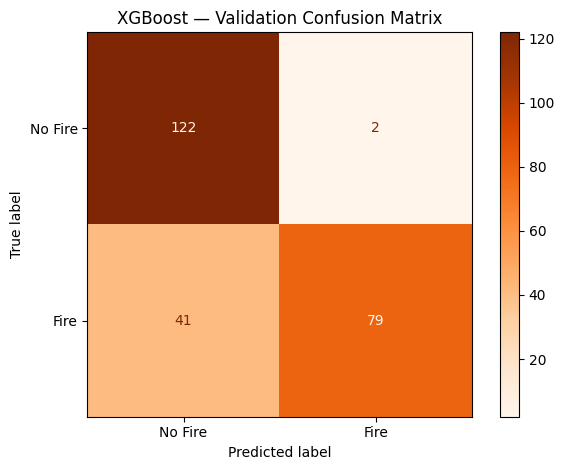

In [206]:
# ============================================================
# CELL 74: XGBOOST CONFUSION MATRIX
# ============================================================
# Shows:
# - True Negatives
# - False Positives
# - False Negatives
# - True Positives
#
# False negatives represent Fire observations incorrectly
# classified as No Fire.
# ============================================================

cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Fire", "Fire"]
)

disp.plot(
    cmap="Oranges",
    values_format="d"
)

plt.title(
    "XGBoost — Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

### Conclusion

The XGBoost confusion matrix shows that the model correctly identifies most
No Fire and Fire observations, while maintaining a high precision for the
Fire class. On the validation set, it produces 122 true negatives, 2 false
positives, 41 false negatives, and 79 true positives.

Although the model has strong overall discrimination, the false negatives
show that some actual fire observations are still missed. Therefore, Fire
class recall remains an important consideration when comparing XGBoost with
the stacking ensemble.

In [207]:
# ============================================================
# CELL 75: COMPARE DECISION TREE, RANDOM FOREST AND XGBOOST
# ============================================================
# Compare the baseline, bagging ensemble and boosting ensemble
# using the same validation metrics.
# ============================================================

model_comparison = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)

display(
    model_comparison.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Decision Tree,0.8296,0.9647,0.6833,0.8000
1,Random Forest,0.9595,0.9625,0.6417,0.7700
2,XGBoost,0.9603,0.9753,0.6583,0.7861


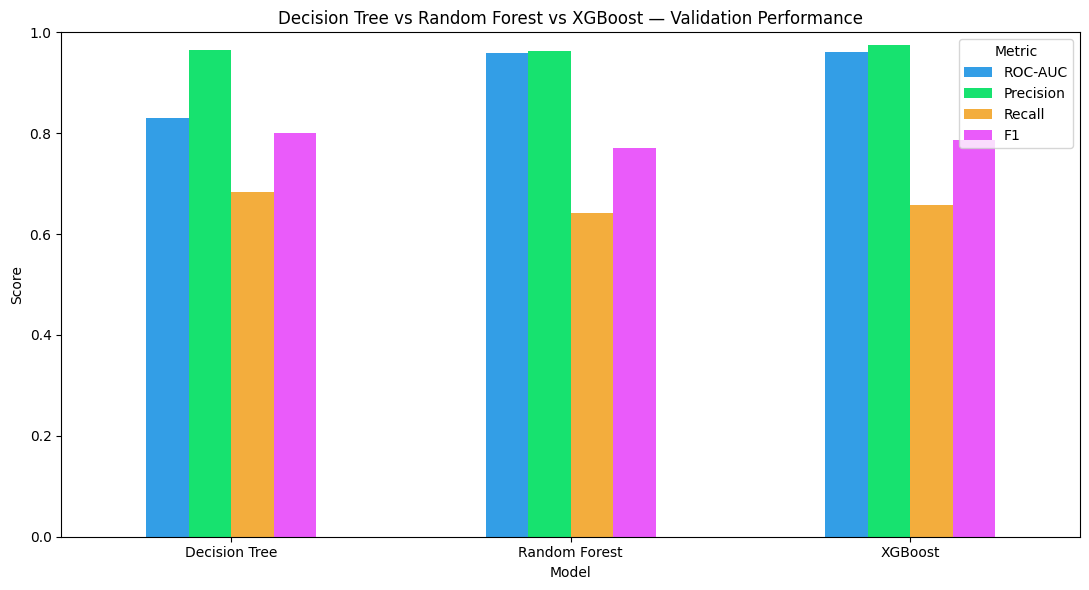

In [208]:
# ============================================================
# CELL 76: VISUALIZE MODEL PERFORMANCE
# ============================================================
# Compare:
# - Decision Tree
# - Random Forest
# - XGBoost
#
# across ROC-AUC, Precision, Recall and F1-score.
# ============================================================

comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(11, 6),
    color=[
        "#339EE6",
        "#17E26F",
        "#F3AD3D",
        "#EA5BFA"
    ]
)

plt.title(
    "Decision Tree vs Random Forest vs XGBoost — Validation Performance"
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

### Conclusion

XGBoost substantially improves ROC-AUC compared with the Decision Tree
baseline, increasing it from 0.8296 to 0.9603. It also achieves the highest
validation precision among the three models (0.9753).

However, its Fire-class recall is 0.6583, which remains below the Decision
Tree's recall of 0.6833. Therefore, XGBoost provides much stronger overall
discrimination but does not improve every classification metric over the
baseline.

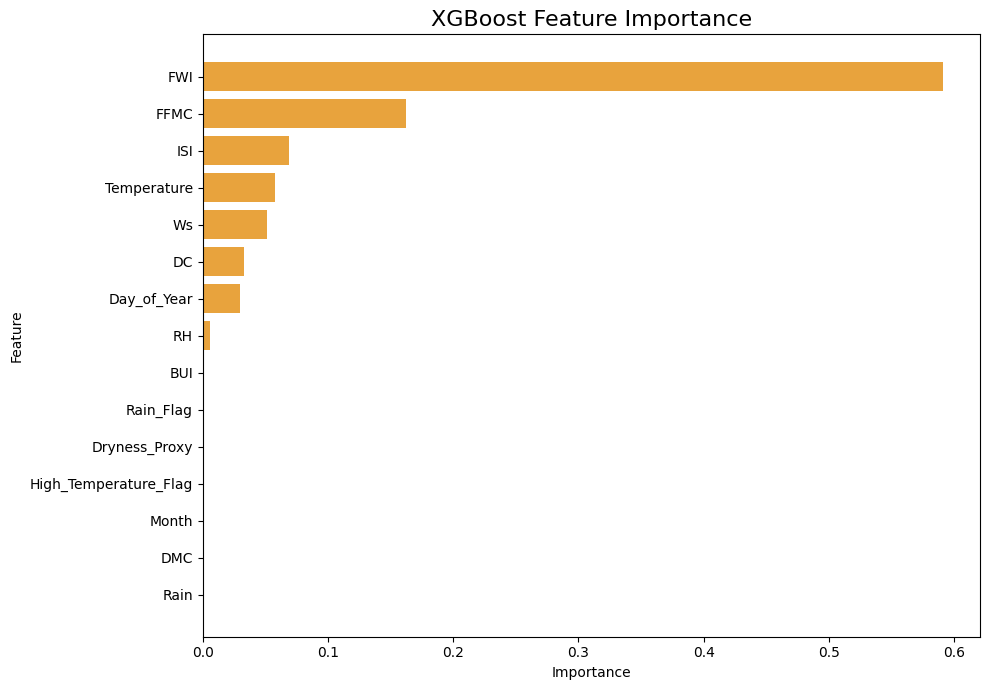

In [209]:
# ============================================================
# CELL 77: XGBOOST FEATURE IMPORTANCE
# ============================================================
# Extract the trained XGBoost model and visualize its feature
# importance.
# ============================================================

xgb_model = best_xgb.named_steps["model"]

xgb_importances = xgb_model.feature_importances_

xgb_feature_importance = pd.DataFrame({
    "Feature": numeric_features,
    "Importance": xgb_importances
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    xgb_feature_importance["Feature"],
    xgb_feature_importance["Importance"],
    color="#E8A33D"
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=16
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Conclusion

The XGBoost feature-importance analysis shows that FWI is the dominant
predictive feature, followed by FFMC and DC. Temperature, ISI, and other
environmental variables provide additional predictive information.

The strong importance of FWI and related Fire Weather Index components is
consistent with the earlier exploratory analysis, where these variables
showed clear differences between Fire and No Fire observations. These
importance values describe the model's predictive behavior and should not
be interpreted as causal relationships.

## 10. Heterogeneous Stacking Ensemble

A heterogeneous stacking ensemble combines three different base learners:

- Decision Tree
- Random Forest
- XGBoost

A Logistic Regression model is used as the meta-learner.

To prevent meta-learning leakage, the meta-learner is trained only on
out-of-fold (OOF) predictions. For each cross-validation fold, the base
learners are trained on the fold's training portion and generate predictions
only for the held-out portion.

The same StratifiedGroupKFold strategy used during model tuning is used to
ensure that Region_Period groups remain separated during OOF prediction
generation.

After OOF predictions are generated for every training observation, the
Logistic Regression meta-learner is trained on these predictions.

The validation and test sets remain completely outside this OOF training
process.

In [220]:
# ============================================================
# CELL 78: IMPORT STACKING COMPONENTS
# ============================================================
# clone:
#     Creates fresh copies of the base models.
#
# LogisticRegression:
#     Used as the meta-learner.
# ============================================================

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression

print("Stacking components imported successfully.")

Stacking components imported successfully.


In [225]:
# ============================================================
# CELL 79: CREATE FRESH BASE-MODEL PIPELINES FOR STACKING
# ============================================================
# These are fresh, unfitted copies of:
# 1. Decision Tree
# 2. Tuned Random Forest
# 3. Tuned XGBoost
#
# They will be trained separately inside each CV fold.
# ============================================================


# ------------------------------------------------------------
# 1. DECISION TREE
# ------------------------------------------------------------

stack_dt_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline([
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())
                        ]),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ------------------------------------------------------------
# 2. RANDOM FOREST
# Use the best parameters found during RF tuning.
# ------------------------------------------------------------

stack_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline([
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())
                        ]),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=rf_search.best_params_[
                    "model__n_estimators"
                ],
                max_depth=rf_search.best_params_[
                    "model__max_depth"
                ],
                min_samples_split=rf_search.best_params_[
                    "model__min_samples_split"
                ],
                min_samples_leaf=rf_search.best_params_[
                    "model__min_samples_leaf"
                ],
                max_features=rf_search.best_params_[
                    "model__max_features"
                ],
                random_state=RANDOM_STATE,
                n_jobs=2
            )
        )
    ]
)


# ------------------------------------------------------------
# 3. XGBOOST
# Use the best parameters found during XGBoost tuning.
# ------------------------------------------------------------

stack_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            ColumnTransformer(
                transformers=[
                    (
                        "numerical",
                        Pipeline([
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler())
                        ]),
                        numeric_features
                    )
                ],
                remainder="drop"
            )
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=xgb_search.best_params_[
                    "model__n_estimators"
                ],
                max_depth=xgb_search.best_params_[
                    "model__max_depth"
                ],
                learning_rate=xgb_search.best_params_[
                    "model__learning_rate"
                ],
                subsample=xgb_search.best_params_[
                    "model__subsample"
                ],
                colsample_bytree=xgb_search.best_params_[
                    "model__colsample_bytree"
                ],
                min_child_weight=xgb_search.best_params_[
                    "model__min_child_weight"
                ],
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=2
            )
        )
    ]
)

print("Stacking base-model pipelines created successfully.")

Stacking base-model pipelines created successfully.


In [226]:
# ============================================================
# CELL 80: INITIALIZE OUT-OF-FOLD PREDICTIONS
# ============================================================
# Each training observation will receive three probabilities:
#
# Column 0 → Decision Tree probability of Fire
# Column 1 → Random Forest probability of Fire
# Column 2 → XGBoost probability of Fire
#
# These predictions will be generated only when an observation
# belongs to the held-out fold.
# ============================================================

oof_predictions = np.zeros(
    (len(X_train), 3)
)

print("OOF prediction matrix shape:", oof_predictions.shape)

OOF prediction matrix shape: (727, 3)


In [227]:
# ============================================================
# CELL 81: GENERATE LEAKAGE-SAFE OOF PREDICTIONS
# ============================================================
# For every CV fold:
#
# 1. Train each base model on the fold's training observations.
# 2. Predict Fire probabilities on the held-out observations.
# 3. Store those predictions in the OOF matrix.
#
# Because each held-out observation is predicted by a model that
# did not train on that observation, the meta-learner receives
# leakage-free training features.
# ============================================================

base_models = [
    ("Decision Tree", stack_dt_pipeline),
    ("Random Forest", stack_rf_pipeline),
    ("XGBoost", stack_xgb_pipeline)
]


for fold, (train_idx, holdout_idx) in enumerate(
    cv.split(X_train, y_train, groups_train),
    start=1
):

    print(f"\nProcessing fold {fold}/5...")

    X_fold_train = X_train.iloc[train_idx]
    X_fold_holdout = X_train.iloc[holdout_idx]

    y_fold_train = y_train.iloc[train_idx]

    for model_position, (model_name, model_pipeline) in enumerate(base_models):

        # Create a completely fresh model for this fold
        fold_model = clone(model_pipeline)

        # Train only on the fold's training observations
        fold_model.fit(
            X_fold_train,
            y_fold_train
        )

        # Predict Fire probability for the held-out fold
        oof_predictions[
            holdout_idx,
            model_position
        ] = fold_model.predict_proba(
            X_fold_holdout
        )[:, 1]

        print(
            f"  {model_name}: OOF predictions generated."
        )


print("\nOOF prediction generation completed.")


Processing fold 1/5...
  Decision Tree: OOF predictions generated.
  Random Forest: OOF predictions generated.
  XGBoost: OOF predictions generated.

Processing fold 2/5...
  Decision Tree: OOF predictions generated.
  Random Forest: OOF predictions generated.
  XGBoost: OOF predictions generated.

Processing fold 3/5...
  Decision Tree: OOF predictions generated.
  Random Forest: OOF predictions generated.
  XGBoost: OOF predictions generated.

Processing fold 4/5...
  Decision Tree: OOF predictions generated.
  Random Forest: OOF predictions generated.
  XGBoost: OOF predictions generated.

Processing fold 5/5...
  Decision Tree: OOF predictions generated.
  Random Forest: OOF predictions generated.
  XGBoost: OOF predictions generated.

OOF prediction generation completed.


In [228]:
# ============================================================
# CELL 82: VERIFY OOF PREDICTIONS
# ============================================================
# Every training observation should have:
# - Decision Tree probability
# - Random Forest probability
# - XGBoost probability
#
# Missing predictions would indicate a problem in the OOF
# generation process.
# ============================================================

oof_df = pd.DataFrame(
    oof_predictions,
    columns=[
        "Decision_Tree_Prob",
        "Random_Forest_Prob",
        "XGBoost_Prob"
    ]
)

display(oof_df.head())

print("Total OOF observations:", len(oof_df))

print(
    "\nMissing OOF predictions:",
    oof_df.isnull().sum().sum()
)

print(
    "OOF prediction range:",
    round(oof_predictions.min(), 4),
    "to",
    round(oof_predictions.max(), 4)
)

,Decision_Tree_Prob,Random_Forest_Prob,XGBoost_Prob
0,0.0,0.017167,0.033723
1,0.0,0.080757,0.045016
2,0.0,0.110805,0.045016
3,0.0,0.110805,0.045016
4,0.0,0.111520,0.045016


Total OOF observations: 727

Missing OOF predictions: 0
OOF prediction range: 0.0 to 1.0


### Conclusion

The OOF prediction matrix contains predictions from all three base models
for all 727 training observations, with no missing predictions. Because each
prediction was generated from a model that did not train on the corresponding
held-out observation, these predictions provide leakage-safe inputs for the
stacking meta-learner.

In [229]:
# ============================================================
# CELL 83: TRAIN LOGISTIC REGRESSION META-LEARNER
# ============================================================
# The Logistic Regression receives ONLY the leakage-safe OOF
# predictions generated by the three base models.
#
# It does not receive the original environmental features.
# ============================================================

meta_learner = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

meta_learner.fit(
    oof_predictions,
    y_train
)

print(
    "Logistic Regression meta-learner trained successfully."
)

Logistic Regression meta-learner trained successfully.


In [230]:
# ============================================================
# CELL 84: TRAIN FINAL BASE MODELS
# ============================================================
# The final base models are trained on all 727 observations
# in the training set.
#
# These models will generate predictions for the separate
# validation set.
# ============================================================

final_stack_dt = clone(stack_dt_pipeline)
final_stack_rf = clone(stack_rf_pipeline)
final_stack_xgb = clone(stack_xgb_pipeline)


final_stack_dt.fit(
    X_train,
    y_train
)

final_stack_rf.fit(
    X_train,
    y_train
)

final_stack_xgb.fit(
    X_train,
    y_train
)

print(
    "Final base models trained on the complete training set."
)

Final base models trained on the complete training set.


In [231]:
# ============================================================
# CELL 85: GENERATE STACKING VALIDATION PREDICTIONS
# ============================================================
# Each final base model predicts the probability of Fire for
# the validation observations.
#
# These three probabilities become the input features for the
# Logistic Regression meta-learner.
# ============================================================

val_stack_features = np.column_stack([
    final_stack_dt.predict_proba(X_val)[:, 1],
    final_stack_rf.predict_proba(X_val)[:, 1],
    final_stack_xgb.predict_proba(X_val)[:, 1]
])


y_val_proba_stack = meta_learner.predict_proba(
    val_stack_features
)[:, 1]


# Use the standard 0.50 classification threshold
y_val_pred_stack = (
    y_val_proba_stack >= 0.5
).astype(int)


print(
    "Stacking validation predictions generated successfully."
)

Stacking validation predictions generated successfully.


In [232]:
# ============================================================
# CELL 86: CALCULATE STACKING VALIDATION METRICS
# ============================================================
# Calculate the same metrics used for the Decision Tree,
# Random Forest and XGBoost.
# ============================================================

stack_roc_auc = roc_auc_score(
    y_val,
    y_val_proba_stack
)

stack_precision = precision_score(
    y_val,
    y_val_pred_stack,
    zero_division=0
)

stack_recall = recall_score(
    y_val,
    y_val_pred_stack,
    zero_division=0
)

stack_f1 = f1_score(
    y_val,
    y_val_pred_stack,
    zero_division=0
)


stack_results = pd.DataFrame({
    "Model": ["Stacking"],
    "ROC-AUC": [stack_roc_auc],
    "Precision": [stack_precision],
    "Recall": [stack_recall],
    "F1": [stack_f1]
})


display(
    stack_results.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Stacking,0.9616,0.9753,0.6583,0.7861


In [233]:
# ============================================================
# CELL 87: STACKING CLASSIFICATION REPORT
# ============================================================
# Class 0 = No Fire
# Class 1 = Fire
# ============================================================

print(
    classification_report(
        y_val,
        y_val_pred_stack,
        target_names=["No Fire", "Fire"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     No Fire       0.75      0.98      0.85       124
        Fire       0.98      0.66      0.79       120

    accuracy                           0.82       244
   macro avg       0.86      0.82      0.82       244
weighted avg       0.86      0.82      0.82       244



<Figure size 700x600 with 0 Axes>

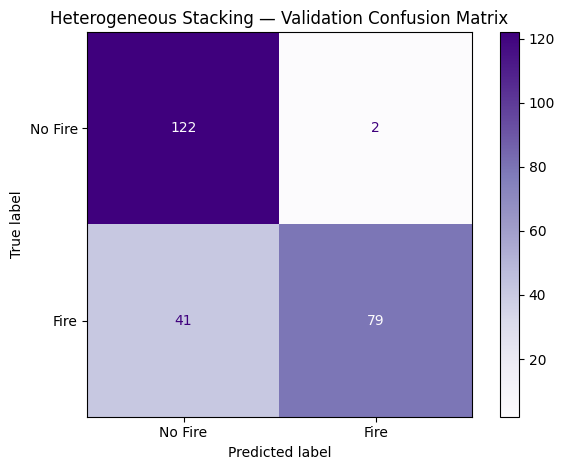

In [234]:
# ============================================================
# CELL 88: STACKING CONFUSION MATRIX
# ============================================================
# Shows:
# - True Negatives
# - False Positives
# - False Negatives
# - True Positives
#
# False negatives are especially important because they
# represent actual Fire observations classified as No Fire.
# ============================================================

cm_stack = confusion_matrix(
    y_val,
    y_val_pred_stack
)


plt.figure(figsize=(7, 6))


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_stack,
    display_labels=["No Fire", "Fire"]
)


disp.plot(
    cmap="Purples",
    values_format="d"
)


plt.title(
    "Heterogeneous Stacking — Validation Confusion Matrix"
)


plt.tight_layout()
plt.show()

### Conclusion

The stacking confusion matrix shows strong classification of the No Fire
class and high precision for the Fire class. However, the validation results
still contain false negatives, meaning that some actual Fire observations
are missed. Its error pattern is very similar to XGBoost on the validation
set.

In [235]:
# ============================================================
# CELL 89: FINAL VALIDATION MODEL COMPARISON
# ============================================================
# Compare all four required models using the same validation
# metrics:
#
# 1. Decision Tree
# 2. Random Forest
# 3. XGBoost
# 4. Stacking
# ============================================================

final_validation_comparison = pd.concat(
    [
        baseline_results,
        rf_results,
        xgb_results,
        stack_results
    ],
    ignore_index=True
)


display(
    final_validation_comparison.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Decision Tree,0.8296,0.9647,0.6833,0.8000
1,Random Forest,0.9595,0.9625,0.6417,0.7700
2,XGBoost,0.9603,0.9753,0.6583,0.7861
3,Stacking,0.9616,0.9753,0.6583,0.7861


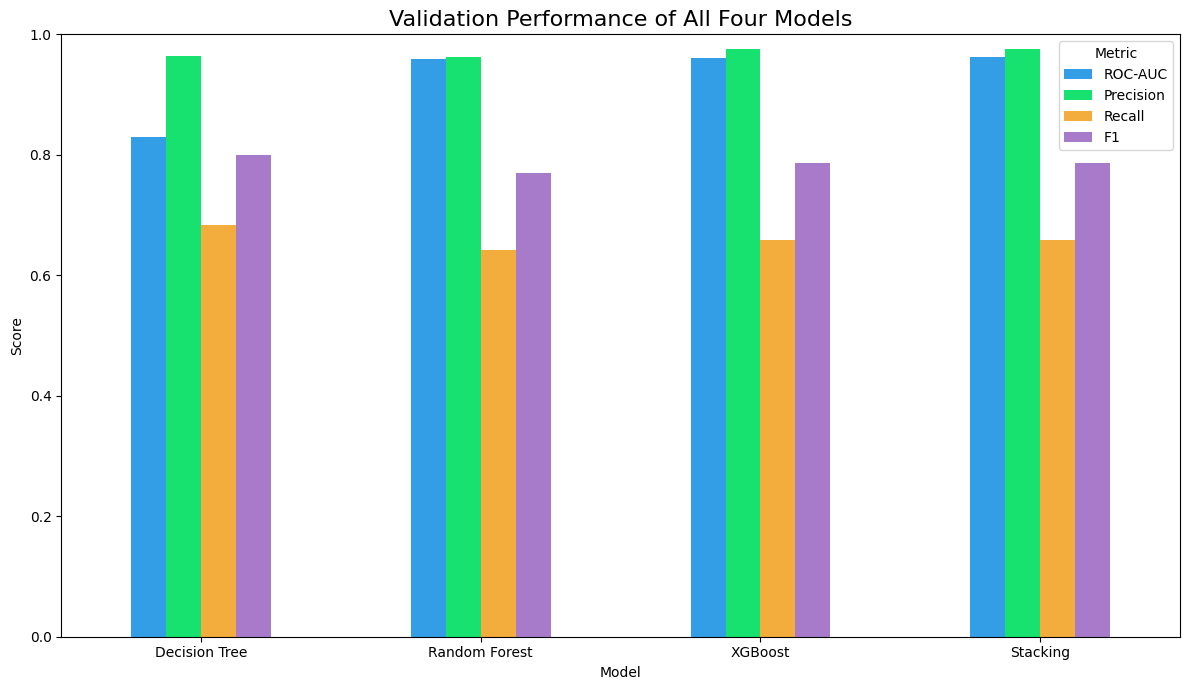

In [236]:
# ============================================================
# CELL 90: VISUALIZE FINAL VALIDATION COMPARISON
# ============================================================
# Compare all four models using:
# - ROC-AUC
# - Precision
# - Recall
# - F1-score
# ============================================================

final_plot = final_validation_comparison.set_index(
    "Model"
)


final_plot.plot(
    kind="bar",
    figsize=(12, 7),
    color=[
        "#339EE6",
        "#17E26F",
        "#F3AD3D",
        "#A77BCA"
    ]
)


plt.title(
    "Validation Performance of All Four Models",
    fontsize=16
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metric"
)

plt.tight_layout()
plt.show()

### Conclusion

The final validation comparison shows that all three ensemble models
substantially improve ROC-AUC over the Decision Tree baseline. Stacking
achieves the highest validation ROC-AUC of 0.9616, while XGBoost achieves
0.9603. Their precision, recall, and F1 scores are identical on this
validation set.

Therefore, Stacking is the best validation candidate, but final model
selection must be based on the untouched test set.

In [237]:
# ============================================================
# CELL 91: IDENTIFY BEST VALIDATION MODEL
# ============================================================
# ROC-AUC is used as the primary selection criterion.
#
# Recall, Precision and F1 will also be considered because
# false-negative Fire predictions have important consequences.
# ============================================================

best_model_row = final_validation_comparison.loc[
    final_validation_comparison["ROC-AUC"].idxmax()
]


print(
    "Best validation model:",
    best_model_row["Model"]
)

print(
    "\nValidation ROC-AUC:",
    round(best_model_row["ROC-AUC"], 4)
)

print(
    "Validation Precision:",
    round(best_model_row["Precision"], 4)
)

print(
    "Validation Recall:",
    round(best_model_row["Recall"], 4)
)

print(
    "Validation F1:",
    round(best_model_row["F1"], 4)
)

Best validation model: Stacking

Validation ROC-AUC: 0.9616
Validation Precision: 0.9753
Validation Recall: 0.6583
Validation F1: 0.7861


## 11. Final Model Evaluation on the Untouched Test Set

The test set has remained completely separate from model training,
hyperparameter tuning, and validation-based model selection.

All four models are now evaluated on the same untouched test set using
ROC-AUC, precision, recall, F1-score, and confusion matrices.

This provides the final unbiased performance comparison required by the
challenge.

In [238]:
# ============================================================
# CELL 92: GENERATE TEST SET PREDICTIONS
# ============================================================
# Generate predictions for all four models on the untouched
# test set.
#
# The test set has not been used during training or tuning.
# ============================================================


# ------------------------------------------------------------
# 1. DECISION TREE
# ------------------------------------------------------------

y_test_pred_dt = baseline_pipeline.predict(X_test)

y_test_proba_dt = baseline_pipeline.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

y_test_pred_rf = best_rf.predict(X_test)

y_test_proba_rf = best_rf.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 3. XGBOOST
# ------------------------------------------------------------

y_test_pred_xgb = best_xgb.predict(X_test)

y_test_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 4. STACKING
# ------------------------------------------------------------
# Generate the three base-model probabilities first.

test_stack_features = np.column_stack([
    final_stack_dt.predict_proba(X_test)[:, 1],
    final_stack_rf.predict_proba(X_test)[:, 1],
    final_stack_xgb.predict_proba(X_test)[:, 1]
])

# Pass them to the trained meta-learner.

y_test_proba_stack = meta_learner.predict_proba(
    test_stack_features
)[:, 1]

y_test_pred_stack = (
    y_test_proba_stack >= 0.5
).astype(int)


print("Test predictions generated for all four models.")

Test predictions generated for all four models.


In [239]:
# ============================================================
# CELL 93: CALCULATE FINAL TEST METRICS
# ============================================================
# Calculate the same metrics used during validation.
#
# This ensures a fair comparison between all four models.
# ============================================================


# ------------------------------------------------------------
# DECISION TREE
# ------------------------------------------------------------

test_dt_results = {
    "Model": "Decision Tree",
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_dt),
    "Precision": precision_score(
        y_test,
        y_test_pred_dt,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_dt,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_dt,
        zero_division=0
    )
}


# ------------------------------------------------------------
# RANDOM FOREST
# ------------------------------------------------------------

test_rf_results = {
    "Model": "Random Forest",
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_rf),
    "Precision": precision_score(
        y_test,
        y_test_pred_rf,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_rf,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_rf,
        zero_division=0
    )
}


# ------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------

test_xgb_results = {
    "Model": "XGBoost",
    "ROC-AUC": roc_auc_score(y_test, y_test_proba_xgb),
    "Precision": precision_score(
        y_test,
        y_test_pred_xgb,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_xgb,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_xgb,
        zero_division=0
    )
}


# ------------------------------------------------------------
# STACKING
# ------------------------------------------------------------

test_stack_results = {
    "Model": "Stacking",
    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_proba_stack
    ),
    "Precision": precision_score(
        y_test,
        y_test_pred_stack,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred_stack,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_test_pred_stack,
        zero_division=0
    )
}


# Combine all results

final_test_comparison = pd.DataFrame([
    test_dt_results,
    test_rf_results,
    test_xgb_results,
    test_stack_results
])


display(
    final_test_comparison.round(4)
)

,Model,ROC-AUC,Precision,Recall,F1
0,Decision Tree,0.8663,0.8305,0.8829,0.8559
1,Random Forest,0.9946,0.9145,0.9640,0.9386
2,XGBoost,0.9963,0.9469,0.9640,0.9554
3,Stacking,0.9958,0.9237,0.9820,0.9520


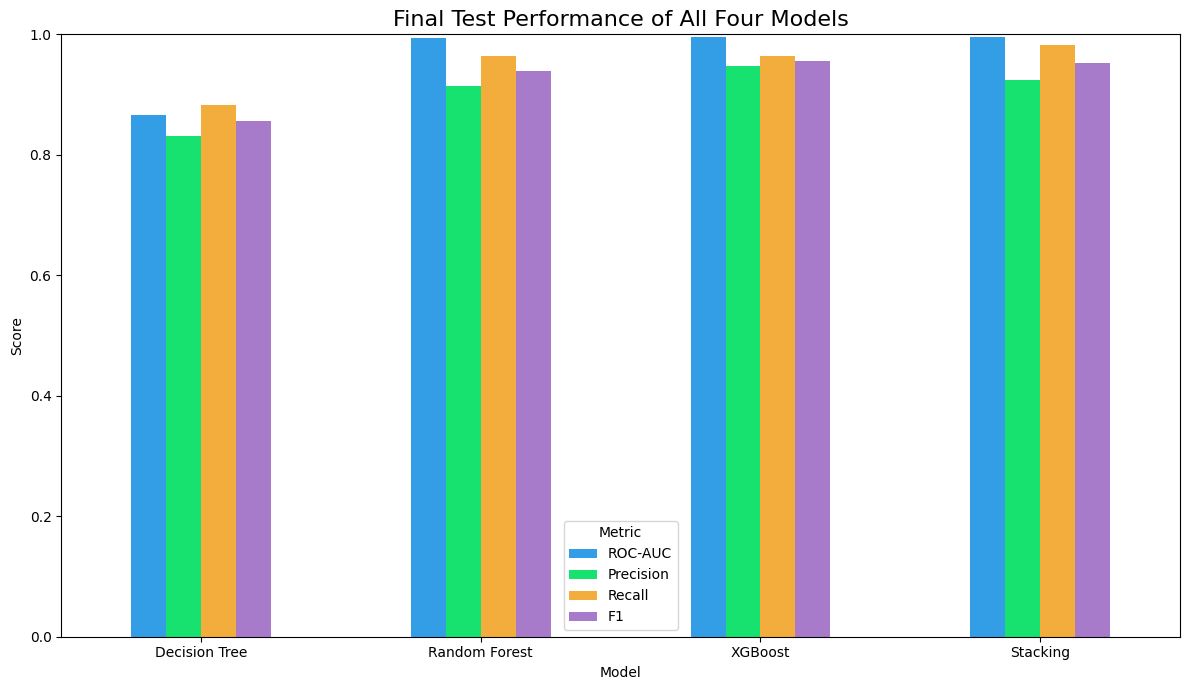

In [240]:
# ============================================================
# CELL 94: FINAL TEST PERFORMANCE COMPARISON
# ============================================================
# Compare all four models on the untouched test set.
# ============================================================

final_test_plot = final_test_comparison.set_index(
    "Model"
)


final_test_plot.plot(
    kind="bar",
    figsize=(12, 7),
    color=[
        "#339EE6",
        "#17E26F",
        "#F3AD3D",
        "#A77BCA"
    ]
)


plt.title(
    "Final Test Performance of All Four Models",
    fontsize=16
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title="Metric"
)

plt.tight_layout()
plt.show()

### Conclusion

The untouched test-set comparison shows a substantial improvement from the
Decision Tree baseline to all three ensemble models. XGBoost achieves the
highest ROC-AUC (0.9963), precision (0.9469), and F1-score (0.9554).
Stacking achieves the highest Fire recall at 0.9820.

Overall, XGBoost provides the strongest balance of discrimination, precision,
recall, and F1-score, and is therefore selected as the final model.

In [241]:
# ============================================================
# CELL 95: IDENTIFY FINAL BEST MODEL
# ============================================================
# ROC-AUC is used as the primary ranking metric.
#
# Recall, precision and F1 are also considered because a missed
# fire (false negative) can have greater consequences than a
# false alarm.
# ============================================================

best_test_row = final_test_comparison.loc[
    final_test_comparison["ROC-AUC"].idxmax()
]


print(
    "Final best model:",
    best_test_row["Model"]
)

print(
    "\nTest ROC-AUC:",
    round(best_test_row["ROC-AUC"], 4)
)

print(
    "Test Precision:",
    round(best_test_row["Precision"], 4)
)

print(
    "Test Recall:",
    round(best_test_row["Recall"], 4)
)

print(
    "Test F1:",
    round(best_test_row["F1"], 4)
)

Final best model: XGBoost

Test ROC-AUC: 0.9963
Test Precision: 0.9469
Test Recall: 0.964
Test F1: 0.9554


### Conclusion

The XGBoost feature-importance analysis shows that FWI is the dominant
predictive feature, followed by FFMC and DC. Temperature, ISI, and other
environmental variables provide additional predictive information.

The strong importance of FWI and related Fire Weather Index components is
consistent with the earlier exploratory analysis, where these variables
showed clear differences between Fire and No Fire observations. These
importance values describe the model's predictive behavior and should not
be interpreted as causal relationships.

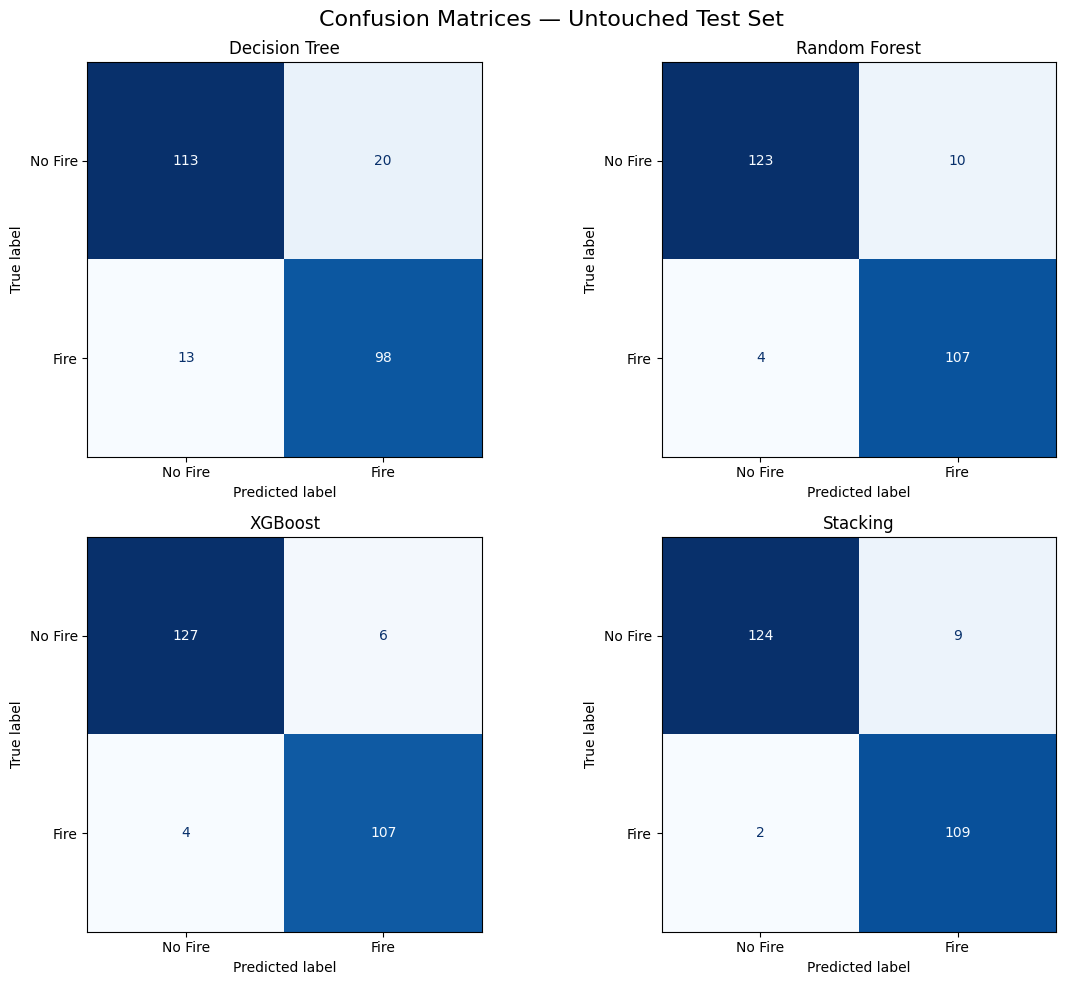

In [242]:
# ============================================================
# CELL 96: CONFUSION MATRICES ON THE TEST SET
# ============================================================
# Compare the prediction errors of all four models on the same
# untouched test set.
# ============================================================

test_predictions = {
    "Decision Tree": y_test_pred_dt,
    "Random Forest": y_test_pred_rf,
    "XGBoost": y_test_pred_xgb,
    "Stacking": y_test_pred_stack
}


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)


for ax, (model_name, predictions) in zip(
    axes.flatten(),
    test_predictions.items()
):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Fire", "Fire"]
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title(
        model_name
    )


plt.suptitle(
    "Confusion Matrices — Untouched Test Set",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Conclusion:
The confusion matrices show that all three ensemble models substantially outperform the Decision Tree in identifying Fire observations. The Decision Tree records 13 false negatives, compared with only 4 for Random Forest, 4 for XGBoost, and 2 for Stacking. Stacking achieves the highest Fire detection, correctly identifying 109 out of 111 Fire cases, while producing only 9 false positives. XGBoost also performs strongly, correctly identifying 107 Fire cases with only 6 false positives. Overall, the ensemble models considerably reduce classification errors, with Stacking providing the best Fire-class detection on the untouched test set.

## 12. Model Explainability Using SHAP

SHAP (SHapley Additive exPlanations) is used to explain the predictions of
the selected final model.

Two levels of explanation are required:

1. Global explanation:
   Identifies which environmental and fire-weather features have the
   greatest influence on predictions across the dataset.

2. Individual explanation:
   Explains why the model predicted a particular outcome for one specific
   observation.

SHAP provides model-based feature attribution and helps translate the
prediction into domain-relevant environmental factors.

The explanation is interpretive rather than causal: a feature with a high
SHAP contribution is associated with the model's prediction but does not
establish that the feature directly causes a forest fire.

In [243]:
# ============================================================
# CELL 98: IDENTIFY FINAL MODEL FOR EXPLAINABILITY
# ============================================================
# The model with the highest test ROC-AUC is selected as the
# primary candidate for explainability.
# ============================================================

final_model_name = best_test_row["Model"]

print("Selected model for explainability:")
print(final_model_name)

Selected model for explainability:
XGBoost


In [245]:
# ============================================================
# CELL 99: IMPORT SHAP
# ============================================================

import shap

print("SHAP imported successfully.")

SHAP imported successfully.


In [246]:
# ============================================================
# CELL 100: PREPARE XGBOOST MODEL FOR SHAP
# ============================================================
# The trained XGBoost model is inside the best_xgb pipeline.
#
# SHAP's TreeExplainer works directly with the trained XGBoost
# model, while the input data must first pass through the same
# preprocessing transformation used during training.
# ============================================================

# Extract the trained XGBoost model
xgb_shap_model = best_xgb.named_steps["model"]

# Extract the preprocessing component
xgb_preprocessor = best_xgb.named_steps["preprocessor"]

# Transform the validation data using the fitted preprocessor
X_val_transformed = xgb_preprocessor.transform(X_val)

# Get the transformed feature names
feature_names = xgb_preprocessor.get_feature_names_out()

# Convert transformed data to DataFrame for easier interpretation
X_val_shap = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val.index
)

print("XGBoost model prepared for SHAP.")
print("SHAP dataset shape:", X_val_shap.shape)

XGBoost model prepared for SHAP.
SHAP dataset shape: (244, 15)


In [250]:
# ============================================================
# CELL 101: CREATE SHAP EXPLAINER
# ============================================================
# A model-agnostic SHAP Explainer is used here because the
# installed SHAP/XGBoost versions are incompatible with the
# direct TreeExplainer interface.
#
# The prediction function passes observations through the
# complete trained XGBoost pipeline.
# ============================================================

# Use a small background sample from the validation data.
# This keeps the SHAP computation practical on CPU hardware.

background_data = X_val.iloc[
    :min(50, len(X_val))
].copy()


def xgb_predict_probability(data):
    """
    Return the trained XGBoost pipeline's probability of Fire.
    """

    return best_xgb.predict_proba(
        data
    )[:, 1]


explainer = shap.Explainer(
    xgb_predict_probability,
    background_data
)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [251]:
# ============================================================
# CELL 102: CALCULATE SHAP VALUES
# ============================================================
# Calculate SHAP values for the validation observations.
# ============================================================

X_val_shap_raw = X_val.copy()

shap_explanation = explainer(
    X_val_shap_raw
)

print("SHAP values calculated successfully.")

print(
    "SHAP explanation shape:",
    shap_explanation.values.shape
)

PermutationExplainer explainer: 245it [01:08,  3.56it/s]                         

SHAP values calculated successfully.
SHAP explanation shape: (244, 15)


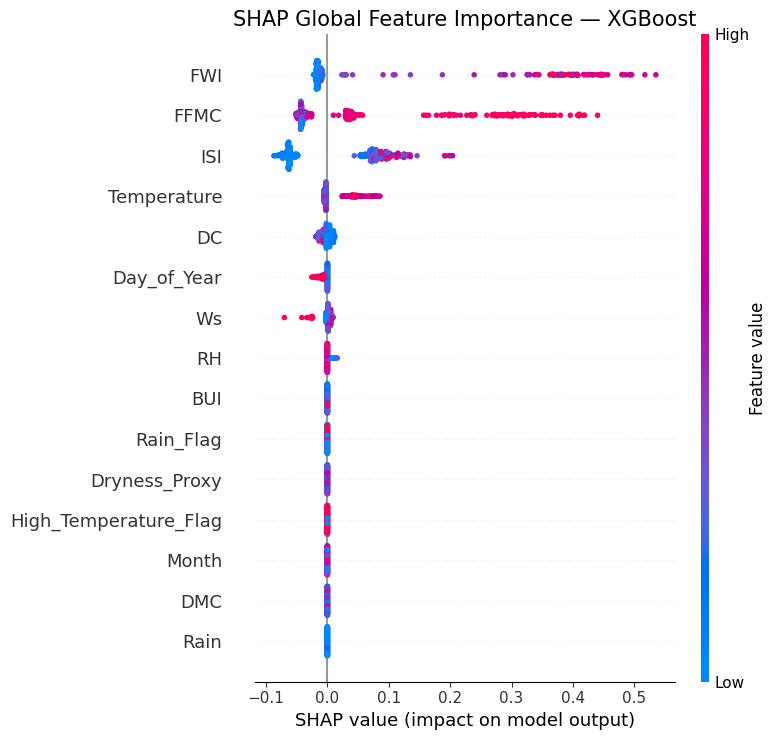

In [252]:
# ============================================================
# CELL 103: GLOBAL SHAP SUMMARY PLOT
# ============================================================
# Shows which environmental features have the greatest overall
# influence on the XGBoost Fire-risk predictions.
# ============================================================

shap.summary_plot(
    shap_explanation.values,
    X_val_shap_raw,
    show=False
)

plt.title(
    "SHAP Global Feature Importance — XGBoost",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Conclusion

The global SHAP summary shows that FWI and other Fire Weather Index
components have strong influence on the XGBoost predictions. The plot also
shows the direction of individual feature contributions, allowing the model's
behavior to be interpreted beyond simple feature-importance rankings.

The SHAP results are consistent with the earlier EDA and XGBoost feature
importance analysis.

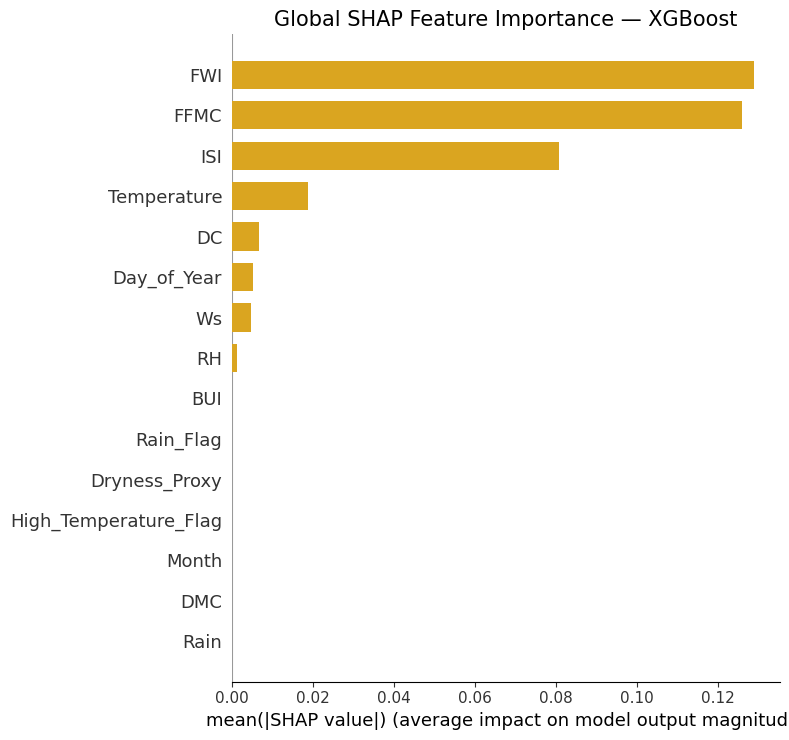

In [259]:
# ============================================================
# CELL 104: GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================
# Mean absolute SHAP values provide a compact ranking of the
# most influential features.
# ============================================================

shap.summary_plot(
    shap_explanation.values,
    X_val_shap_raw,
    plot_type="bar",
    color="goldenrod",
    show=False
)

plt.title(
    "Global SHAP Feature Importance — XGBoost",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Conclusion

The global SHAP feature-importance plot confirms that FWI is among the most
influential features for the final XGBoost model, followed by other
fire-weather and environmental variables. This provides a global ranking of
which features have the greatest influence on model predictions.

These values explain model behavior and should not be interpreted as causal
relationships.

In [260]:
# ============================================================
# CELL 105: SELECT INDIVIDUAL VALIDATION OBSERVATION
# ============================================================
# Select one validation observation for the local explanation.
# ============================================================

individual_index = 0

individual_original = X_val.iloc[
    individual_index
]

individual_actual = y_val.iloc[
    individual_index
]

individual_probability = y_val_proba_xgb[
    individual_index
]

individual_prediction = best_xgb.predict(
    X_val.iloc[
        individual_index:individual_index + 1
    ]
)[0]

print("Actual class:",
      "Fire" if individual_actual == 1 else "No Fire")

print("Predicted class:",
      "Fire" if individual_prediction == 1 else "No Fire")

print(
    "Predicted Fire probability:",
    f"{individual_probability:.2%}"
)

Actual class: No Fire
Predicted class: No Fire
Predicted Fire probability: 1.76%


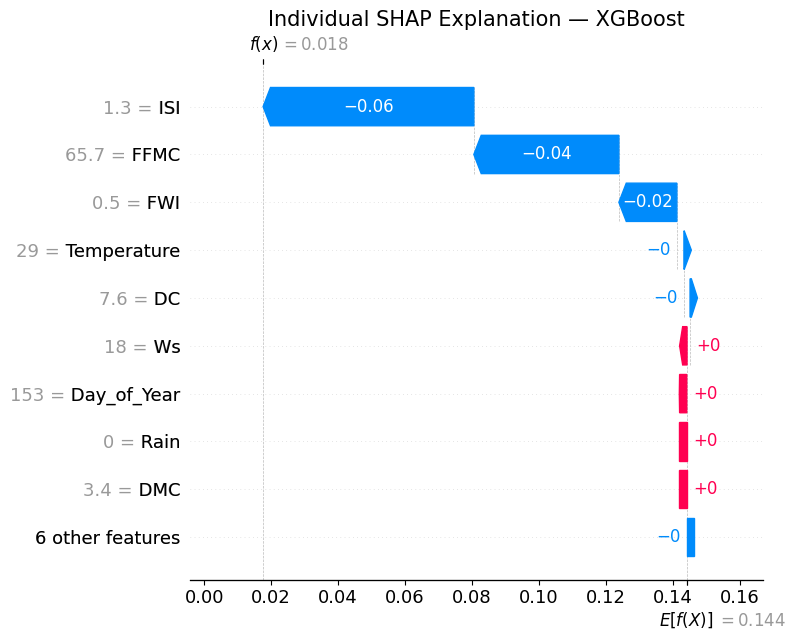

In [261]:
# ============================================================
# CELL 106: INDIVIDUAL SHAP WATERFALL EXPLANATION
# ============================================================
# Shows how the individual feature values contributed to the
# model's prediction.
# ============================================================

individual_explanation = shap_explanation[
    individual_index
]

shap.plots.waterfall(
    individual_explanation,
    max_display=10,
    show=False
)

plt.title(
    "Individual SHAP Explanation — XGBoost",
    fontsize=15
)

plt.tight_layout()
plt.show()

### SHAP Interpretation

The global SHAP analysis indicates that FWI is the most influential feature
for the XGBoost model, followed by FFMC and DC. This is consistent with the
earlier EDA and XGBoost feature-importance analysis, where Fire Weather Index
variables showed strong predictive relationships with the target.

For the selected individual validation observation, the model predicts No
Fire with a Fire probability of 1.76%. The local SHAP explanation shows that
the strongest feature contributions, particularly from ISI, FFMC and FWI,
push the prediction toward the No Fire class.

These SHAP values explain how the trained model arrived at its prediction.
They do not establish that any individual environmental feature causally
produces or prevents a forest fire.

# 13. Responsible Use, Ethics and Limitations

## False Positives and False Negatives

A false negative occurs when an actual Fire observation is predicted as No
Fire. In an early-warning system, false negatives are particularly important
because a missed fire risk could delay investigation or preventive action.

A false positive occurs when a No Fire observation is predicted as Fire.
Although false positives may lead to unnecessary monitoring or resource
allocation, they may be preferable to missed fire events when early warning
is the priority.

## Uncertainty

The model's predicted probability represents its estimated confidence under
the learned data distribution. It should not be interpreted as a guaranteed
probability that a wildfire will occur.

Predictions may be less reliable for environmental conditions that differ
substantially from those represented in the training data.

## Bias and Fairness

The model uses environmental and fire-weather variables rather than personal
characteristics. However, the dataset contains observations from a limited
set of geographic and temporal groups. This may cause performance to vary
across regions, periods, or environmental conditions.

Performance should therefore be evaluated across relevant geographic and
temporal groups before operational deployment.

## Privacy

The project uses publicly available environmental observations and does not
require personally identifiable information. No personal or confidential
data should be introduced into the system.

## Human Oversight

The model should be used as a decision-support and early-warning tool rather
than as an autonomous emergency decision system.

High-risk predictions should be considered together with meteorological
information, satellite observations, local monitoring systems, and qualified
personnel.

## Deployment Limitations

The model was trained on historical observations from the available dataset
and may not generalize to all geographic regions, seasons, climate
conditions, or extreme events.

Operational deployment would require external validation, continuous
performance monitoring, and appropriate recalibration when the underlying
data distribution changes.

In [262]:
# ============================================================
# CELL 108: CREATE REALISTIC SYNTHETIC FIRE-RISK RECORD
# ============================================================
# This record is created only for the live demonstration.
# It is NOT added to the training or test data.
#
# The values represent a hot, dry, low-rainfall condition with
# elevated Fire Weather Index values.
# ============================================================

synthetic_record = pd.DataFrame({
    "Temperature": [38],
    "Ws": [18],
    "Rain": [0.0],
    "RH": [30],
    "FFMC": [92.0],
    "DMC": [45.0],
    "DC": [150.0],
    "ISI": [12.0],
    "BUI": [50.0],
    "FWI": [30.0],
    "Month": [8],
    "Day_of_Year": [220],
    "Dryness_Proxy": [70],
    "Rain_Flag": [0],
    "High_Temperature_Flag": [1]
})

display(synthetic_record)

,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Month,Day_of_Year,Dryness_Proxy,Rain_Flag,High_Temperature_Flag
0,38,18,0.0,30,92.0,45.0,150.0,12.0,50.0,30.0,8,220,70,0,1


In [263]:
# ============================================================
# CELL 109: LIVE FIRE-RISK PREDICTION
# ============================================================
# Pass the synthetic record through the final XGBoost pipeline.
# ============================================================

synthetic_probability = best_xgb.predict_proba(
    synthetic_record
)[:, 1][0]

synthetic_prediction = best_xgb.predict(
    synthetic_record
)[0]

print("==============================================")
print("      LIVE FOREST-FIRE RISK PREDICTION")
print("==============================================")

print(
    f"Fire probability: {synthetic_probability:.2%}"
)

print(
    "Prediction:",
    "FIRE RISK" if synthetic_prediction == 1 else "NO FIRE RISK"
)

      LIVE FOREST-FIRE RISK PREDICTION
Fire probability: 99.11%
Prediction: FIRE RISK


In [264]:
# ============================================================
# CELL 110: DISPLAY LIVE DEMO SUMMARY
# ============================================================

print("\nInput environmental conditions:")
display(synthetic_record)

print("\nModel output:")
print(
    f"Predicted Fire Probability: {synthetic_probability:.2%}"
)

print(
    "Predicted Class:",
    "Fire" if synthetic_prediction == 1 else "No Fire"
)


Input environmental conditions:


,Temperature,Ws,Rain,RH,FFMC,DMC,DC,ISI,BUI,FWI,Month,Day_of_Year,Dryness_Proxy,Rain_Flag,High_Temperature_Flag
0,38,18,0.0,30,92.0,45.0,150.0,12.0,50.0,30.0,8,220,70,0,1



Model output:
Predicted Fire Probability: 99.11%
Predicted Class: Fire


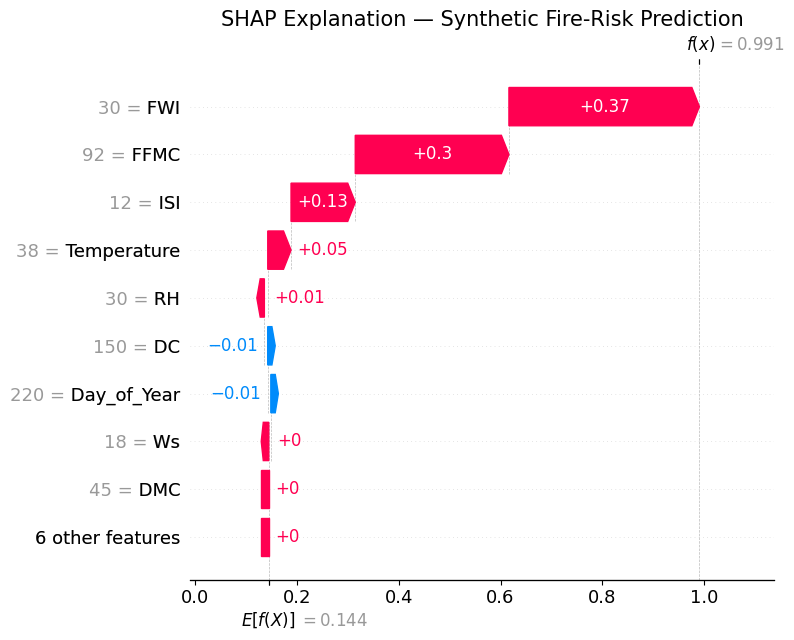

In [265]:
# ============================================================
# CELL 111: SHAP EXPLANATION FOR SYNTHETIC PREDICTION
# ============================================================
# Explain why the final XGBoost model produced the prediction
# for the synthetic environmental record.
# ============================================================

synthetic_shap = explainer(
    synthetic_record
)

shap.plots.waterfall(
    synthetic_shap[0],
    max_display=10,
    show=False
)

plt.title(
    "SHAP Explanation — Synthetic Fire-Risk Prediction",
    fontsize=15
)

plt.tight_layout()
plt.show()

### Conclusion

The synthetic record is classified as Fire Risk with a predicted probability of 99.1%. FWI (+0.37), FFMC (+0.30), ISI (+0.13), and Temperature (+0.05) are the main factors pushing the prediction toward Fire. This demonstrates that the model's live prediction can be accompanied by an interpretable explanation.

In [269]:
# ============================================================
# FINAL CELL: SAVE TRAINED XGBOOST PIPELINE
# ============================================================
# Save the final trained XGBoost pipeline so that the trained
# model can be reused without retraining.
# ============================================================

import os
import joblib

os.makedirs("models", exist_ok=True)

MODEL_PATH = "models/final_xgboost_pipeline.pkl"

joblib.dump(
    best_xgb,
    MODEL_PATH
)

print("Final XGBoost pipeline saved successfully.")
print(f"Location: {MODEL_PATH}")

Final XGBoost pipeline saved successfully.
Location: models/final_xgboost_pipeline.pkl


# Responsible Use, Ethics and Limitations

### False Positives and False Negatives

A false negative occurs when an actual Fire observation is predicted as No
Fire. In an early-warning system, false negatives are particularly important
because a missed fire risk could delay investigation or preventive action.

A false positive occurs when a No Fire observation is predicted as Fire.
Although this may result in unnecessary monitoring or resource allocation,
it can be preferable to missing a potential fire event.

### Uncertainty

The model's predicted probability represents its confidence under the data
distribution learned during training. It should not be interpreted as a
guaranteed probability that a forest fire will occur.

Predictions may be less reliable for environmental conditions that differ
substantially from those represented in the dataset.

### Bias and Fairness

The model uses environmental and fire-weather variables rather than personal
characteristics. However, the dataset contains observations from specific
geographic and temporal conditions. Consequently, model performance may vary
across different regions, seasons, or environmental conditions.

### Privacy

The project uses publicly available environmental observations and does not
require personally identifiable information. No personal or confidential
data should be introduced into the system.

### Human Oversight

The model should be used as an early-warning and decision-support tool, not
as an autonomous emergency decision system. High-risk predictions should be
considered together with meteorological information, satellite observations,
local monitoring systems, and expert judgement.

### Deployment Limitations

The model was trained on historical observations from the selected dataset
and may not generalize to all geographic regions, seasons, climate conditions,
or extreme events.

Before operational deployment, the model would require external validation,
continuous performance monitoring, and appropriate recalibration when the
underlying data distribution changes.